## Описание проекта

**Заголовок:** Разработка модели машинного обучения для хозяйства "Вольный луг".

**Описание проекта:** Фермер хозяйства хочет купить бурёнок, чтобы расширить поголовье стада коров. Для этого он заключил выгодный контракт с ассоциацией пастбищ «ЭкоФерма». Условия позволяют фермеру очень тщательно отобрать коров. Он определяет качество молока по строгой методике, и при этом ему нужно выполнять свой план развития молочного хозяйства. Фермер хочет, чтобы каждая бурёнка давала не менее 6000 килограммов молока в год, а её надой был вкусным — строго по его критериям, ничуть не хуже. «ЭкоФерма» готова предоставить подробные данные о своих коровах.

**Цель проекта:** Разработать две модели машинного обучения, которые помогут фермеру управлять рисками и принимать решения о покупке коров, на основе предсказанных данных о качестве (целевой признак - `Вкус молока`) и количестве удоя (целевой признак - `Удой`).

**Ход проекта:** 
- Описание данных предоставленное "ЭкоФерма"
- Подготовка данных: загрузка, описание, анализ общей информации из датасетов "ЭкоФермы"
- Предообработка данных: пропуски, дубликаты, типы данных
- Исследовательский анализ данных: статистический анализ
- Корреляционный анализ признаков в датасете `ferma_main.csv`
- Задача регрессии
- Задача классификации
- Выводы

**Общий вывод:** резюмирование полученных результатов, формулировка ключевых выводов и рекомендаций

С помощью данного исследования мы стремимся дать прогнозы вкуса молока и удоя коров "Экофермы", описать работу полученных моделей для того, чтобы фермер "Вольного луга" мог принимать взвешанные решения о покупке коров и расширении своего бизнеса в дальнейшем.

### Описание данных

Файл `ferma_main.csv` содержит данные о стаде фермера на текущий момент.  

- `id` — уникальный идентификатор коровы.  
- `Удой`, кг — масса молока, которую корова даёт в год (в килограммах).  
- `ЭКЕ` (Энергетическая кормовая единица) — показатель питательности корма коровы.  
- `Сырой протеин`, г — содержание сырого протеина в корме (в граммах).  
- `СПО` (Сахаро-протеиновое соотношение) — отношение сахара к протеину в корме коровы.  
- `Порода` — порода коровы.  
- `Тип пастбища` — ландшафт лугов, на которых паслась корова.  
- `порода папы_быка` — порода папы коровы.  
- `Жирность`,% — содержание жиров в молоке (в процентах).  
- `Белок`,% — содержание белков в молоке (в процентах).  
- `Вкус молока` — оценка вкуса по личным критериям фермера, бинарный признак (вкусно, не вкусно).  
- `Возраст` — возраст коровы, бинарный признак (менее_2_лет, более_2_лет).  

Файл `ferma_dad.csv` хранит имя папы каждой коровы в стаде фермера.  

- `id` — уникальный идентификатор коровы.  
- `Имя Папы` — имя папы коровы.  

Файл `cow_buy.csv` — это данные о коровах «ЭкоФермы», которых фермер хочет изучить перед покупкой.  

- `Порода` — порода коровы.  
- `Тип пастбища` — ландшафт лугов, на которых паслась корова.  
- `порода папы_быка` — порода папы коровы.  
- `Имя_папы` — имя папы коровы.  
- `Текущая_жирность`,% — содержание жиров в молоке (в процентах).  
- `Текущий_уровень_белок`,% — содержание белков в молоке (в процентах).  
- `Возраст` — возраст коровы, бинарный признак (менее_2_лет, более_2_лет).  


Признаки в датасете `ferma_main.csv` можно разделить на группы:  
Характеристики коровы: `id`, `Порода`, `порода папы_быка`, `Возраст`.  
Характеристики корма: `ЭКЕ` (Энергетическая кормовая единица), `Сырой протеин`, г, `СПО` (Сахаро-протеиновое соотношение).  
Характеристика пастбища: `Тип пастбища`.  
Характеристики молока: `Удой`, кг, `Жирность`,%, `Белок`,%, `Вкус молока`.  

Данные в файлах ferma_main.csv и cow_buy.csv похожи, но у датасета cow_buy.csv несколько особенностей.  

Содержание белков и жиров в молоке указано на момент продажи — когда «ЭкоФерма» давала коровам свой корм.  

Параметры корма ЭКЕ (Энергетическая кормовая единица), Сырой протеин, г и СПО (Сахаро-протеиновое соотношение) отсутствуют. Технологи заказчика пересмотрели подход к кормлению: для новых коров планируется увеличить значения каждого из этих параметров на 5%.  

Кроме того, отсутствуют признаки Удой, кг и Вкус молока. Это целевые признаки, именно их предстоит предсказать!

## Импорт библиотек

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pylab
import warnings
import seaborn as sns
from scipy import stats as st
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn. metrics import precision_recall_curve

warnings.filterwarnings("ignore")

## Загрузка данных и общая информация о данных

In [2]:
#Функция для импорта в df
def import_data(way):
    data_path = os.path.join('..', 'data', way)
    data = pd.read_csv(data_path, sep=';')
    return data

In [3]:
ferma_main = import_data('ferma_main.csv')
ferma_dad = import_data('ferma_dad.csv')
cow_buy = import_data('cow_buy.csv')

In [4]:
#Функция для проверки df
def information(data):
    print('-'*20)
    display(data.head(10))
    print('-'*20)
    print(data.info())
    print('-'*20)
    print('Количество дубликатов:', data.duplicated().sum())
    print('-'*20)
    display(data.describe())
    print('-'*20)
    print(f'''Пропусков:
{data.isna().sum()}''')
    print('-'*20)
    print(f'''Размер датафрейма: {data.shape}''')
    print('-'*20)

### Датафрейм ferma_main

In [5]:
information(ferma_main)

--------------------


,id,"Удой, кг",ЭКЕ (Энергетическая кормовая единица),"Сырой протеин, г",СПО (Сахаро-протеиновое соотношение),Порода,Тип пастбища,порода папы_быка,"Жирность,%","Белок,%",Вкус молока,Возраст
0,1,5863,"14,2",1743,"0,89",Вис Бик Айдиал,Равнинное,Айдиал,"3,58","3,076",вкусно,более_2_лет
1,2,5529,"12,8",2138,"0,89",Вис Бик Айдиал,Равнинные,Соверин,"3,54","3,079",вкусно,менее_2_лет
2,3,5810,14,1854,"0,885",РефлешнСоверинг,Холмистое,Соверин,"3,59","3,074",не вкусно,более_2_лет
3,4,5895,"12,4",2012,"0,885",РефлешнСоверинг,Холмистое,Айдиал,"3,4","3,075",не вкусно,более_2_лет
4,5,5302,"12,8",1675,"0,885",Вис Бик Айдиал,Равнинные,Соверин,"3,73","3,073",вкусно,менее_2_лет
5,6,5254,"12,7",1806,"0,885",РефлешнСоверинг,Холмистое,Соверин,"3,13","3,078",вкусно,менее_2_лет
6,7,5910,"13,2",1792,"0,885",Вис Бик Айдиал,Равнинные,Соверин,"3,48","3,077",вкусно,более_2_лет
7,8,6179,"14,7",1806,"0,93",Вис Бик Айдиал,Равнинные,Айдиал,"3,55","3,076",вкусно,более_2_лет
8,9,6783,"14,2",1918,"0,94",РефлешнСоверинг,Холмистое,Айдиал,"3,71","3,077",вкусно,более_2_лет
9,10,5339,"13,4",1791,"0,895",Вис Бик Айдиал,Холмистое,Соверин,"3,13","3,075",вкусно,менее_2_лет


--------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 634 entries, 0 to 633
Data columns (total 12 columns):
 #   Column                                 Non-Null Count  Dtype 
---  ------                                 --------------  ----- 
 0   id                                     634 non-null    int64 
 1   Удой, кг                               634 non-null    int64 
 2   ЭКЕ (Энергетическая кормовая единица)  634 non-null    object
 3   Сырой протеин, г                       634 non-null    int64 
 4   СПО (Сахаро-протеиновое соотношение)   634 non-null    object
 5   Порода                                 634 non-null    object
 6   Тип пастбища                           634 non-null    object
 7   порода папы_быка                       634 non-null    object
 8   Жирность,%                             634 non-null    object
 9   Белок,%                                634 non-null    object
 10  Вкус молока                            634 non-null    object
 11

,id,"Удой, кг","Сырой протеин, г"
count,634.000000,634.000000,634.000000
mean,317.460568,6187.025237,1922.682965
std,183.096982,1638.401021,182.392548
min,1.000000,5204.000000,1660.000000
25%,159.250000,5751.750000,1772.250000
50%,317.500000,6130.500000,1880.500000
75%,475.750000,6501.000000,2058.750000
max,629.000000,45616.000000,2349.000000


--------------------
Пропусков:
id                                       0
Удой, кг                                 0
ЭКЕ (Энергетическая кормовая единица)    0
Сырой протеин, г                         0
СПО (Сахаро-протеиновое соотношение)     0
Порода                                   0
Тип пастбища                             0
порода папы_быка                         0
Жирность,%                               0
Белок,%                                  0
Вкус молока                              0
Возраст                                  0
dtype: int64
--------------------
Размер датафрейма: (634, 12)
--------------------


В датафрейме с данными о стаде фермера обнаружены следующие ошибки:

- Некорректное наименование столбцов
- Неверные форматы данных в столбцах: `ЭКЕ (Энергетическая кормовая единица)`, `СПО (Сахаро-протеиновое соотношение)`, `Жирность`, `Белок`.

Пропусков не наблюдается.  
Дубликаты имеются явные, требуется проверка на неявные.  
Весовые значения `Удой` и `Сырой протеин` необходимо привести к одной ед. измерения    
Колонки `Вкус молока` и `Возраст` состоят из значения с которыми неудобно работать, потребуется кодирование.  

In [6]:
ferma_main.columns

Index(['id', 'Удой, кг', 'ЭКЕ (Энергетическая кормовая единица)',
       'Сырой протеин, г', 'СПО (Сахаро-протеиновое соотношение)', 'Порода',
       'Тип пастбища', 'порода папы_быка', 'Жирность,%', 'Белок,%',
       'Вкус молока', 'Возраст'],
      dtype='object')

В идеале, как мне кажется, необходимо поменять все наименования под PEP8.


Уберем пояснения в скобках, ед.измерения, нижние подчеркивания.

In [7]:
ferma_main = ferma_main.rename(
    columns={
        'Удой, кг': 'milk_yield',
        "ЭКЕ (Энергетическая кормовая единица)": "feed_energy",
        "Сырой протеин, г": "crude_protein",
        "СПО (Сахаро-протеиновое соотношение)" : "sugar_protein_ratio",
        "Порода": "breed",
        "Тип пастбища" : "pasture_type",
        "порода папы_быка" : "dads_breed",
        "Жирность,%" : "fat_content",
        "Белок,%" : "protein",
        "Вкус молока" : "milk_taste",
        "Возраст" : "age"
    }
)

In [8]:
ferma_main.columns

Index(['id', 'milk_yield', 'feed_energy', 'crude_protein',
       'sugar_protein_ratio', 'breed', 'pasture_type', 'dads_breed',
       'fat_content', 'protein', 'milk_taste', 'age'],
      dtype='object')

### Датафрейм ferma_dad

In [9]:
information(ferma_dad)

--------------------


,id,Имя Папы
0,1,Буйный
1,2,Соловчик
2,3,Барин
3,4,Буйный
4,5,Барин
5,6,Барин
6,7,Соловчик
7,8,Геркулес
8,9,Буйный
9,10,Барин


--------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 629 entries, 0 to 628
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        629 non-null    int64 
 1   Имя Папы  629 non-null    object
dtypes: int64(1), object(1)
memory usage: 10.0+ KB
None
--------------------
Количество дубликатов: 0
--------------------


,id
count,629.00000
mean,315.00000
std,181.72094
min,1.00000
25%,158.00000
50%,315.00000
75%,472.00000
max,629.00000


--------------------
Пропусков:
id          0
Имя Папы    0
dtype: int64
--------------------
Размер датафрейма: (629, 2)
--------------------


В датафрейме с данными об отцах каждой коровы ошибок не наблюдаю.

In [10]:
ferma_dad = ferma_dad.rename(
    columns = {
        "Имя Папы" : "dads_name"
    }
)

In [11]:
ferma_dad.columns

Index(['id', 'dads_name'], dtype='object')

### Датафрейм cow_buy

In [12]:
information(cow_buy)

--------------------


,Порода,Тип пастбища,порода папы_быка,Имя_папы,"Текущая_жирность,%","Текущий_уровень_белок,%",Возраст
0,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,"3,58","3,076",более_2_лет
1,Вис Бик Айдиал,равнинное,Соверин,Буйный,"3,54","3,081",менее_2_лет
2,РефлешнСоверинг,равнинное,Соверин,Барин,"3,59","3,074",более_2_лет
3,РефлешнСоверинг,холмистое,Айдиал,Буйный,"3,4","3,061",более_2_лет
4,РефлешнСоверинг,равнинное,Айдиал,Буйный,"3,64","3,074",более_2_лет
5,РефлешнСоверинг,равнинное,Соверин,Геркулес,"3,63","3,053",менее_2_лет
6,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,"3,58","3,076",более_2_лет
7,Вис Бик Айдиал,равнинное,Соверин,Буйный,"3,57","3,079",более_2_лет
8,РефлешнСоверинг,равнинное,Соверин,Барин,"3,59","3,074",более_2_лет
9,РефлешнСоверинг,холмистое,Айдиал,Буйный,"3,4","3,079",менее_2_лет


--------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Порода                   20 non-null     object
 1   Тип пастбища             20 non-null     object
 2   порода папы_быка         20 non-null     object
 3   Имя_папы                 20 non-null     object
 4   Текущая_жирность,%       20 non-null     object
 5   Текущий_уровень_белок,%  20 non-null     object
 6   Возраст                  20 non-null     object
dtypes: object(7)
memory usage: 1.2+ KB
None
--------------------
Количество дубликатов: 4
--------------------


,Порода,Тип пастбища,порода папы_быка,Имя_папы,"Текущая_жирность,%","Текущий_уровень_белок,%",Возраст
count,20,20,20,20,20,20,20
unique,2,2,2,4,12,12,2
top,РефлешнСоверинг,равнинное,Соверин,Буйный,"3,4","3,074",более_2_лет
freq,11,11,12,8,3,5,15


--------------------
Пропусков:
Порода                     0
Тип пастбища               0
порода папы_быка           0
Имя_папы                   0
Текущая_жирность,%         0
Текущий_уровень_белок,%    0
Возраст                    0
dtype: int64
--------------------
Размер датафрейма: (20, 7)
--------------------


В датафрейме с данными о стаде "ЭкоФермы" обнаружены следующие ошибки:

- Некорректное наименование столбцов
- Неверные форматы данных в столбцах: `Текущая_жирность`, `Текущий_уровень_белок`.

Пропусков не наблюдается.  
Дубликаты имеются явные, требуется проверка на неявные.  
Колонка `Возраст` состоит из значений с которыми неудобно работать, потребуется кодирование.  

In [13]:
cow_buy.columns

Index(['Порода', 'Тип пастбища', 'порода папы_быка', 'Имя_папы',
       'Текущая_жирность,%', 'Текущий_уровень_белок,%', 'Возраст'],
      dtype='object')

In [14]:
cow_buy = cow_buy.rename(
    columns = {
        "Порода": "breed",
        "Тип пастбища": "pasture_type",
        "порода папы_быка": "dads_breed",
        "Имя_папы": "dads_name",
        "Текущая_жирность,%": "fat_content",
        "Текущий_уровень_белок,%": "protein",
        "Возраст": "age"
    }
)

In [15]:
cow_buy.columns

Index(['breed', 'pasture_type', 'dads_breed', 'dads_name', 'fat_content',
       'protein', 'age'],
      dtype='object')

### Вывод

Поправили наименования колонок. Посмотрели на данные. 
Общая информация о датасетах предопределила последующие шаги в предобработке данных:
- изменение форматов данных в некоторых столбцах
- поиск неявных дубликатов
- удаление явных и неявных дубликтов



### Предобработка данных

В датафрейме `ferma_main` изменим типы данных в следующих колонках: `feed_energy`,`sugar_protein_ratio`,`fat_content`,`protein`.

In [16]:
for column in ['feed_energy','sugar_protein_ratio','fat_content','protein']:
    if ferma_main[column].dtypes == object:
        ferma_main[column] = ferma_main[column].str.replace(',', '.').astype(float)
ferma_main.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 634 entries, 0 to 633
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   634 non-null    int64  
 1   milk_yield           634 non-null    int64  
 2   feed_energy          634 non-null    float64
 3   crude_protein        634 non-null    int64  
 4   sugar_protein_ratio  634 non-null    float64
 5   breed                634 non-null    object 
 6   pasture_type         634 non-null    object 
 7   dads_breed           634 non-null    object 
 8   fat_content          634 non-null    float64
 9   protein              634 non-null    float64
 10  milk_taste           634 non-null    object 
 11  age                  634 non-null    object 
dtypes: float64(4), int64(3), object(5)
memory usage: 59.6+ KB


В датафрейме `cow_buy` изменим типы данных в следующих колонках: `fat_content`,`protein`.

In [17]:
for column in ['fat_content','protein']:
    if cow_buy[column].dtypes == object:
        cow_buy[column] = cow_buy[column].str.replace(',', '.').astype(float)
cow_buy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   breed         20 non-null     object 
 1   pasture_type  20 non-null     object 
 2   dads_breed    20 non-null     object 
 3   dads_name     20 non-null     object 
 4   fat_content   20 non-null     float64
 5   protein       20 non-null     float64
 6   age           20 non-null     object 
dtypes: float64(2), object(5)
memory usage: 1.2+ KB


### Дубликаты

In [18]:
def preprocessing (data):
    print('Количество явных дубликатов:', data.duplicated().sum())
    display(data[data.duplicated()])
    data = data.drop_duplicates()
    print('Количество явных дубликатов после удаления:', data.duplicated().sum(), end = '\n'*2)
    
    for column in data.columns[data.dtypes=='object']:
        print(f'''Количество уникальных значений в столбце `{column}`: {data[column].nunique()}''')
        print(data[column].unique(), end='\n'*2)
        
    return data

In [19]:
ferma_main = preprocessing(ferma_main)

Количество явных дубликатов: 5


,id,milk_yield,feed_energy,crude_protein,sugar_protein_ratio,breed,pasture_type,dads_breed,fat_content,protein,milk_taste,age
629,627,5970,14.4,1837,0.88,РефлешнСоверинг,Холмистое,Соверин,3.64,3.075,не вкусно,более_2_лет
630,627,5970,14.4,1837,0.88,РефлешнСоверинг,Холмистое,Соверин,3.64,3.075,не вкусно,более_2_лет
631,627,5970,14.4,1837,0.88,РефлешнСоверинг,Холмистое,Соверин,3.64,3.075,не вкусно,более_2_лет
632,627,5970,14.4,1837,0.88,РефлешнСоверинг,Холмистое,Соверин,3.64,3.075,не вкусно,более_2_лет
633,627,5970,14.4,1837,0.88,РефлешнСоверинг,Холмистое,Соверин,3.64,3.075,не вкусно,более_2_лет


Количество явных дубликатов после удаления: 0

Количество уникальных значений в столбце `breed`: 2
['Вис Бик Айдиал' 'РефлешнСоверинг']

Количество уникальных значений в столбце `pasture_type`: 3
['Равнинное' 'Равнинные' 'Холмистое']

Количество уникальных значений в столбце `dads_breed`: 3
['Айдиал' 'Соверин' 'Айдиалл']

Количество уникальных значений в столбце `milk_taste`: 2
['вкусно' 'не вкусно']

Количество уникальных значений в столбце `age`: 2
['более_2_лет' 'менее_2_лет']



То есть у нас была строчка с id 627, и она повторялась 5 раз в датафрейме, удалив дубликаты, у нас осталась одна оригинальная 627 строчка. Нужно следить, какие данные мы удаляем из датафрейма `ferma_main`, так как при обучении модели мы будем потом присоединять к ней данные из ferma_dad по ключу id.

In [20]:
cow_buy = preprocessing(cow_buy)

Количество явных дубликатов: 4


,breed,pasture_type,dads_breed,dads_name,fat_content,protein,age
6,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,3.58,3.076,более_2_лет
8,РефлешнСоверинг,равнинное,Соверин,Барин,3.59,3.074,более_2_лет
14,РефлешнСоверинг,равнинное,Соверин,Барин,3.59,3.074,более_2_лет
19,РефлешнСоверинг,равнинное,Айдиал,Буйный,3.64,3.074,более_2_лет


Количество явных дубликатов после удаления: 0

Количество уникальных значений в столбце `breed`: 2
['Вис Бик Айдиал' 'РефлешнСоверинг']

Количество уникальных значений в столбце `pasture_type`: 2
['холмистое' 'равнинное']

Количество уникальных значений в столбце `dads_breed`: 2
['Айдиал' 'Соверин']

Количество уникальных значений в столбце `dads_name`: 4
['Геркулес' 'Буйный' 'Барин' 'Соловчик']

Количество уникальных значений в столбце `age`: 2
['более_2_лет' 'менее_2_лет']



В датафрейме `ferma_main` наблюдаются неявные дубликаты в столбцах: `pasture_type`, `dads_breed`. Приведем их в порядок, согласно значениям из `cow_buy`

In [21]:
ferma_main['pasture_type'] = ferma_main['pasture_type'].str.replace('Равнинные', 'равнинное')
ferma_main['pasture_type'] = ferma_main['pasture_type'].str.replace('Холмистое', 'холмистое')

ferma_main['dads_breed'] = ferma_main['dads_breed'].str.replace('Айдиалл', 'Айдиал')

In [22]:
ferma_main['pasture_type'].unique()

array(['Равнинное', 'равнинное', 'холмистое'], dtype=object)

In [23]:
ferma_main['dads_breed'].unique()

array(['Айдиал', 'Соверин'], dtype=object)

In [24]:
ferma_dad = preprocessing(ferma_dad)

Количество явных дубликатов: 0


,id,dads_name


Количество явных дубликатов после удаления: 0

Количество уникальных значений в столбце `dads_name`: 4
['Буйный' 'Соловчик' 'Барин' 'Геркулес']



### Обработка значений

In [25]:
# переименование значений df_main
ferma_main.loc[ferma_main['breed'] == 'РефлешнСоверинг', 'breed'] = 'Рефлешн Соверинг'
for columns in ['breed', 'pasture_type', 'dads_breed', 'milk_taste']:
    ferma_main[columns] = ferma_main[columns].str.lower()

# переименование значений df_dad
for columns in ['dads_name']:
    ferma_dad[columns] = ferma_dad[columns].str.lower()

# переименование значений df_cow
cow_buy.loc[cow_buy['breed'] == 'РефлешнСоверинг', 'breed'] = 'Рефлешн Соверинг'
for columns in ['breed', 'pasture_type', 'dads_breed', 'dads_name']:
    cow_buy[columns] = cow_buy[columns].str.lower()

### Вывод

Проверили данные на дубликаты, выявили неявные и удалили.  
Привели наименования к PEP8.   
Поменяли типы данных в колонках где это было необходимо для последующего анализа.  
Пропущенных значений в данных нет.

## Исследовательский анализ данных

In [26]:
ferma_main.describe()

,id,milk_yield,feed_energy,crude_protein,sugar_protein_ratio,fat_content,protein
count,629.00000,629.000000,629.000000,629.000000,629.000000,629.000000,629.000000
mean,315.00000,6188.750397,14.543879,1923.364070,0.913116,3.603657,3.075671
std,181.72094,1644.795489,1.306408,182.956251,0.032203,0.168656,0.002549
min,1.00000,5204.000000,10.900000,1660.000000,0.840000,2.990000,3.069000
25%,158.00000,5751.000000,13.500000,1771.000000,0.890000,3.590000,3.074000
50%,315.00000,6133.000000,14.700000,1888.000000,0.930000,3.650000,3.076000
75%,472.00000,6501.000000,15.600000,2062.000000,0.940000,3.720000,3.077000
max,629.00000,45616.000000,16.800000,2349.000000,0.960000,3.750000,3.085000


In [27]:
ferma_main.sort_values(by='milk_yield', ascending=False).head()

,id,milk_yield,feed_energy,crude_protein,sugar_protein_ratio,breed,pasture_type,dads_breed,fat_content,protein,milk_taste,age
16,17,45616,11.5,1675,0.93,вис бик айдиал,холмистое,айдиал,3.22,3.076,вкусно,более_2_лет
70,71,7222,16.8,2157,0.95,вис бик айдиал,холмистое,айдиал,3.70,3.076,вкусно,более_2_лет
135,136,7207,16.6,2343,0.94,вис бик айдиал,холмистое,айдиал,3.72,3.078,вкусно,более_2_лет
296,297,7201,15.8,2077,0.94,рефлешн соверинг,холмистое,айдиал,3.71,3.072,вкусно,более_2_лет
294,295,7197,15.6,2241,0.94,рефлешн соверинг,холмистое,айдиал,3.71,3.075,вкусно,более_2_лет


Среди значений обнаружено аномальное значение удоя. Данное значение единственное. Им можно пренебречь

In [28]:
# удаление выброса
ferma_main = ferma_main[ferma_main['milk_yield'] < 8000]
# удаление связанной строки в таблице df_dad
ferma_dad = ferma_dad[~(ferma_dad['id'] == 17)]

In [29]:
ferma_main.shape[0] == ferma_dad.shape[0]

True

### Визуализация признаков `ferma_main`

In [30]:
def viz_cat_variable(df, column, title):
    sns.countplot(data = df, x=column)

    plt.suptitle(title)
    plt.show()

In [31]:
def viz_num_variable(df, column, title):
    sns.set(rc={"figure.figsize": (18, 5)})

    fig,axes=plt.subplots(1,2)

    sns.histplot(data=df[column], ax=axes[0])
    axes[0].set(ylabel='Количество коров', xlabel=column)

    sns.boxplot(data=df[column], ax=axes[1])
    axes[1].set(ylabel=column)

    plt.suptitle(title)
    plt.show()

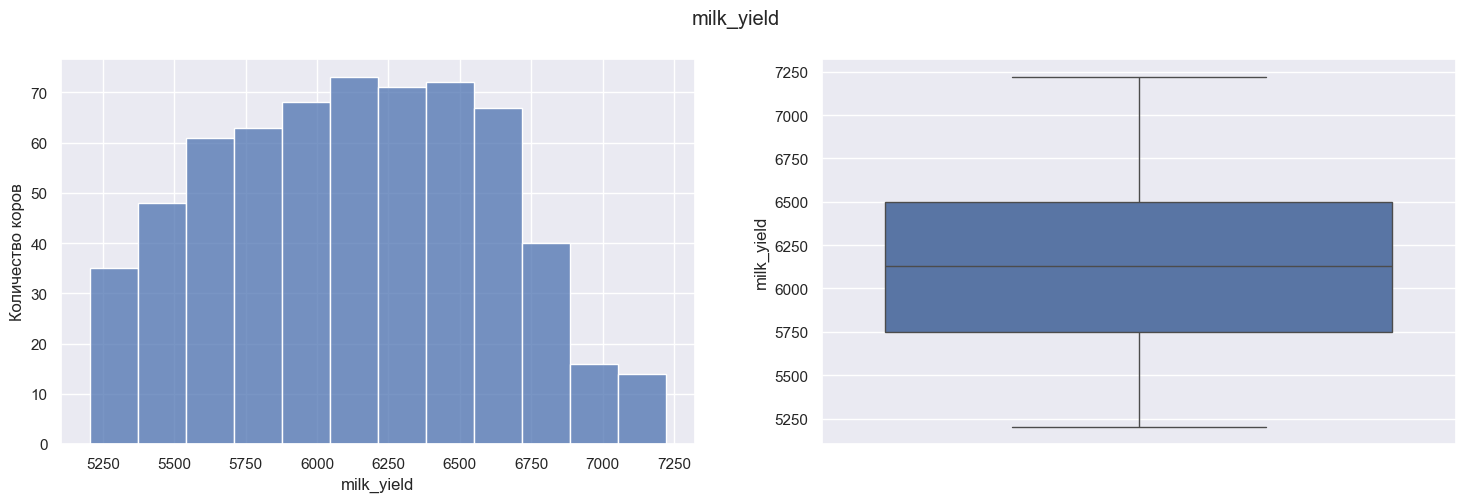

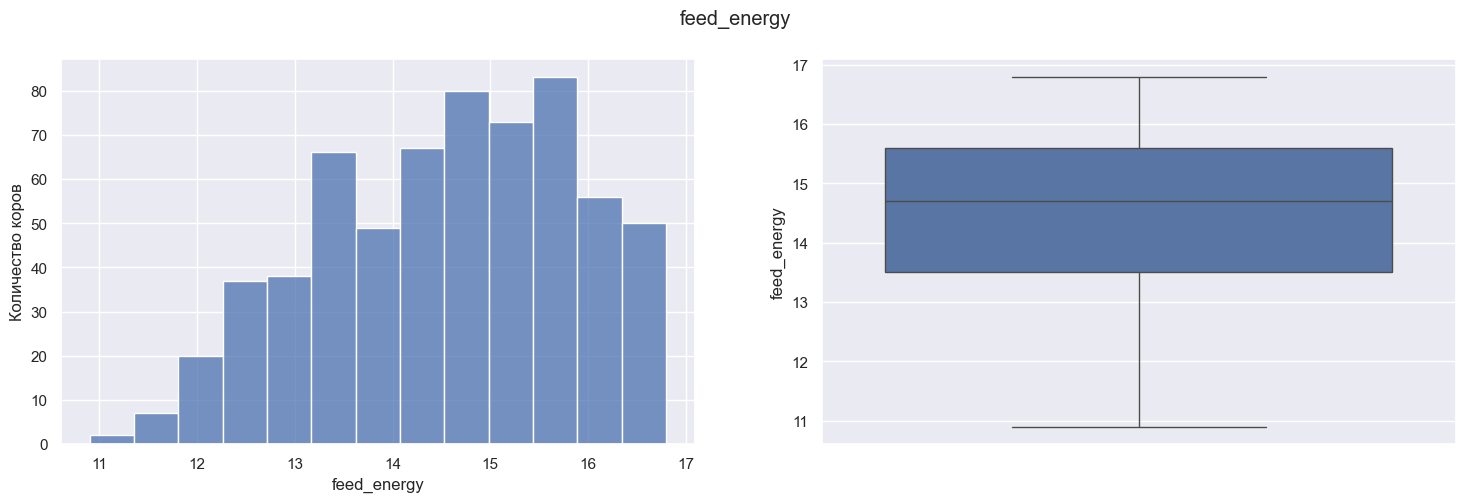

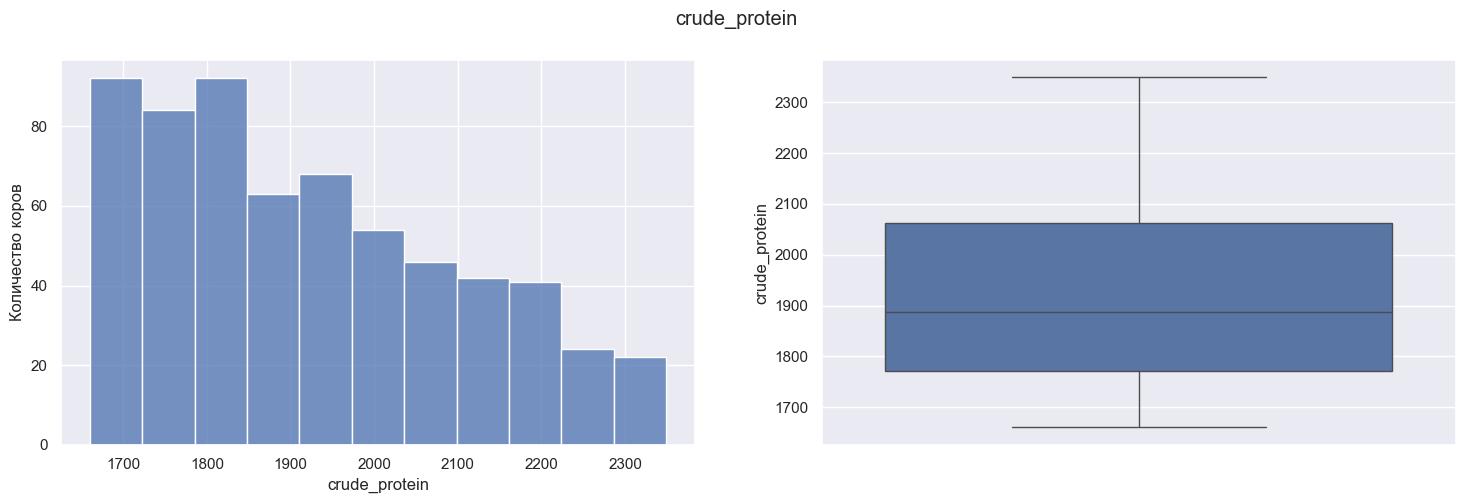

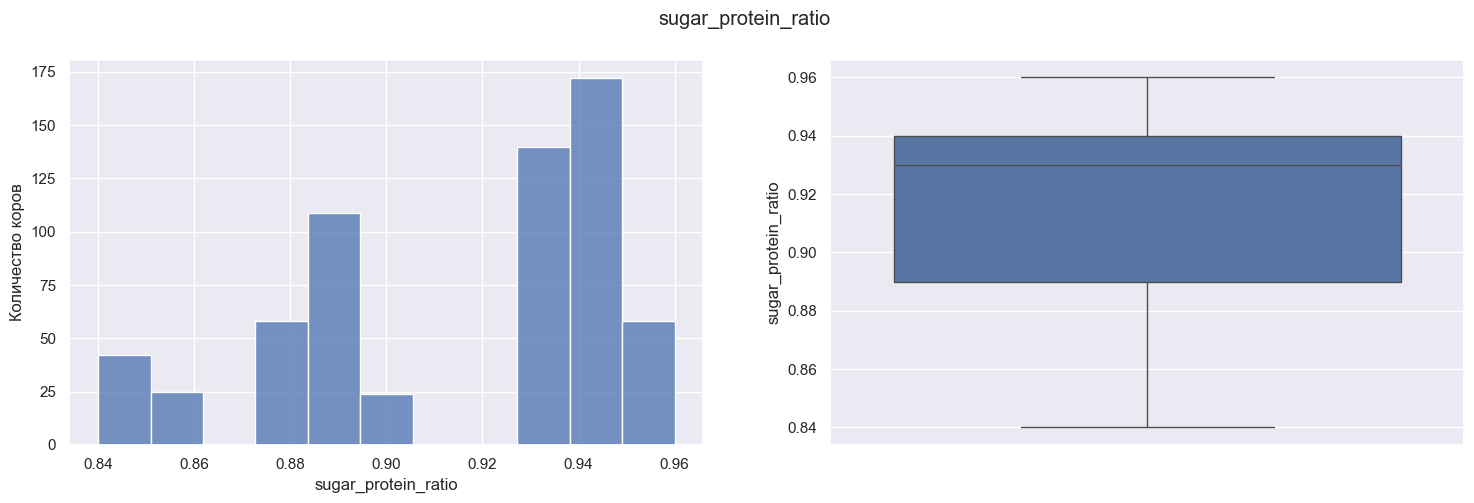

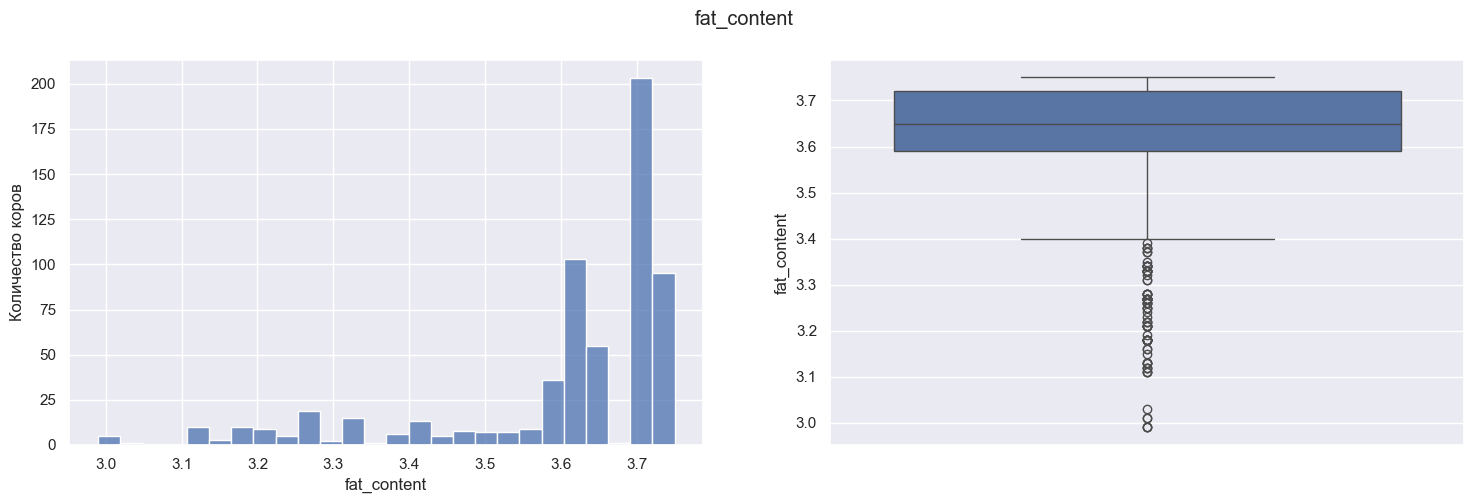

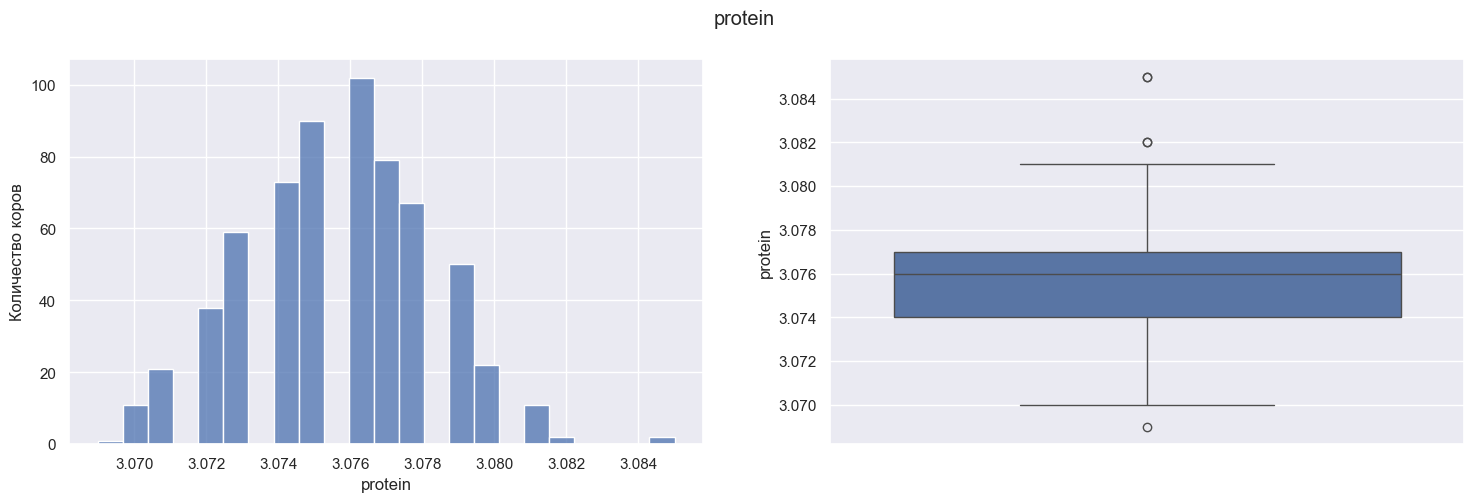

In [32]:
for col in ferma_main:
    if ferma_main[col].dtype!=object and col!='id':
        viz_num_variable(ferma_main, col, col)

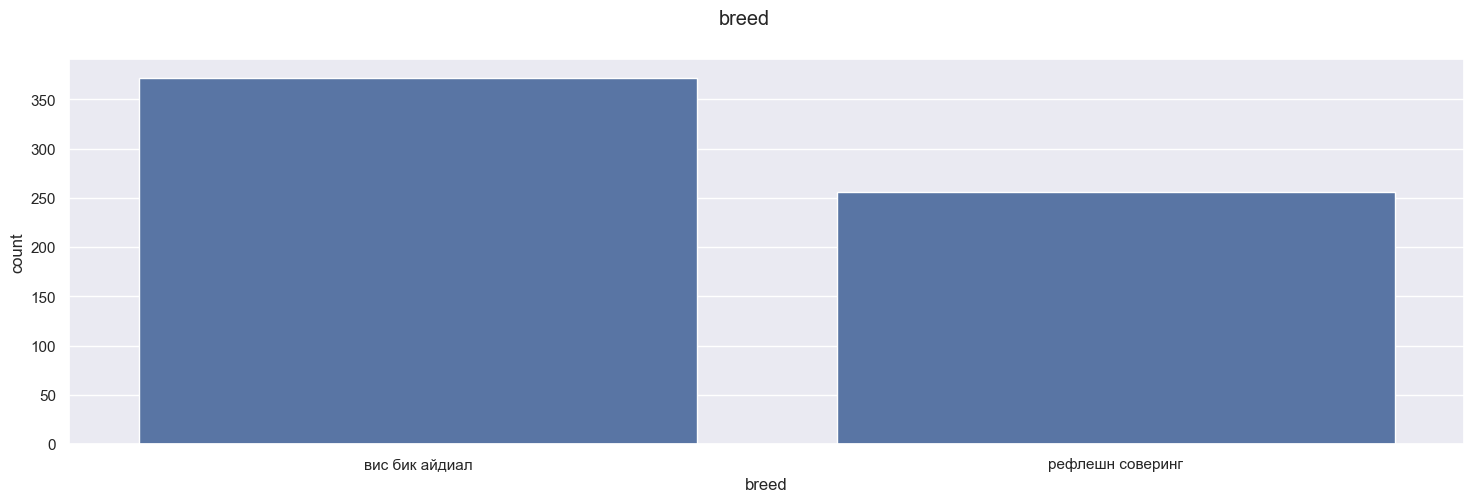

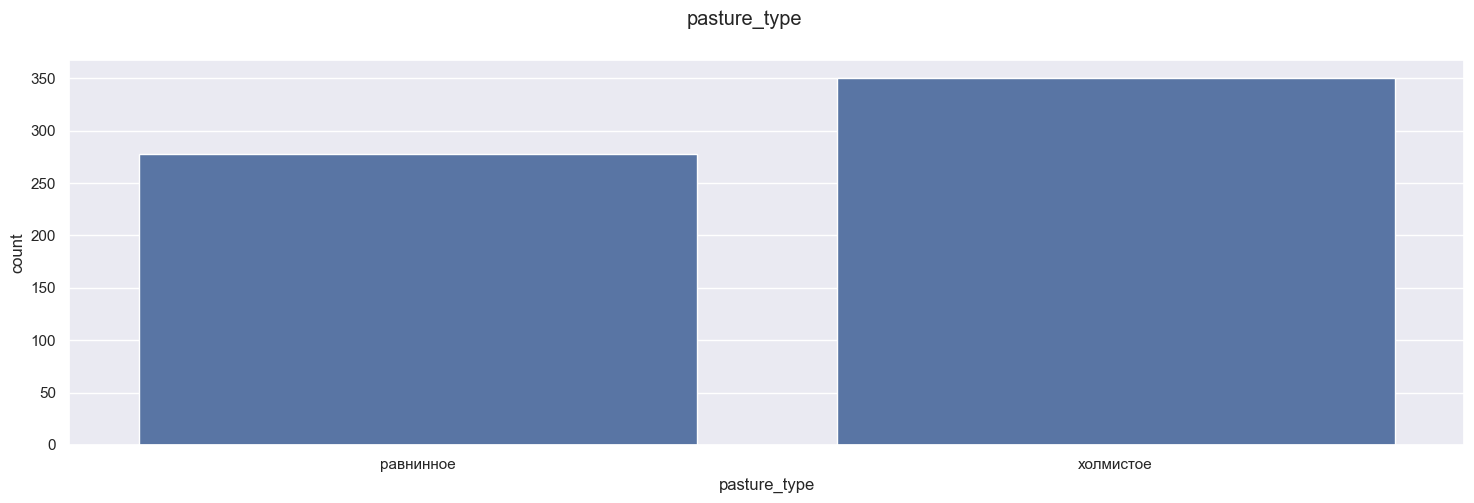

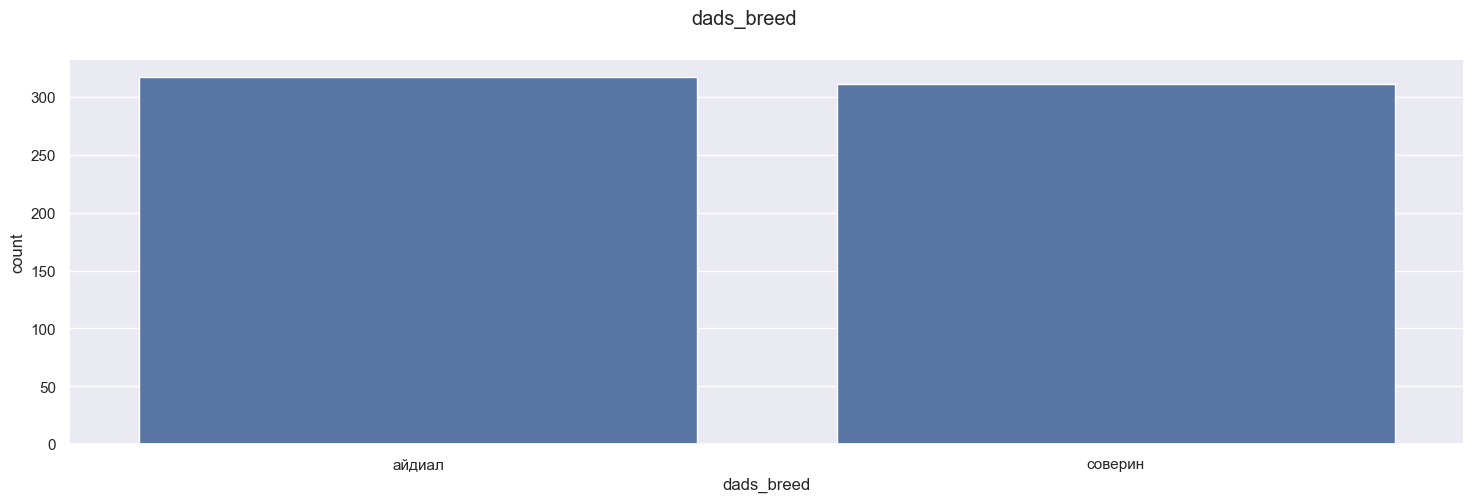

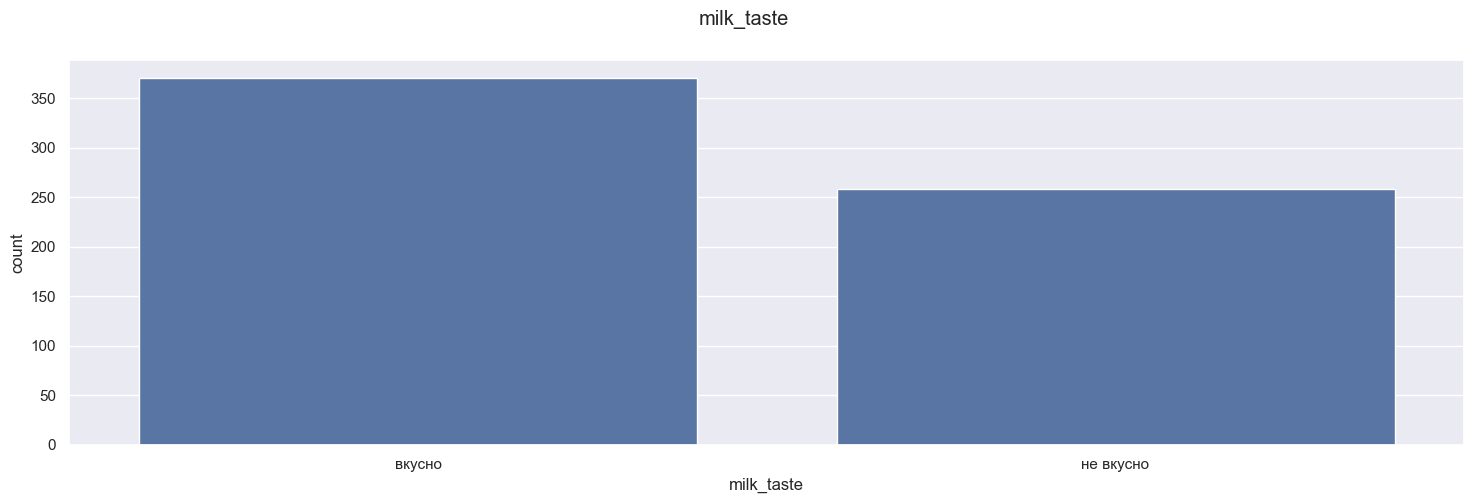

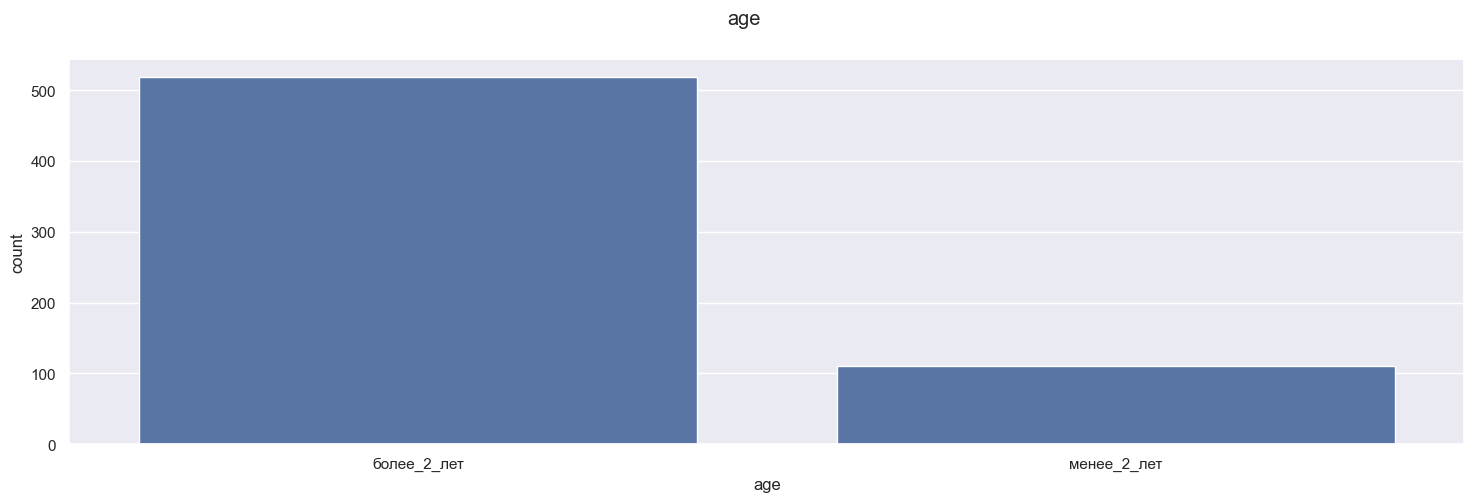

In [33]:
for col in ferma_main:
    if ferma_main[col].dtype==object and col!='id':
        viz_cat_variable(ferma_main, col, col)

### Визуализация признаков `ferma_dad`

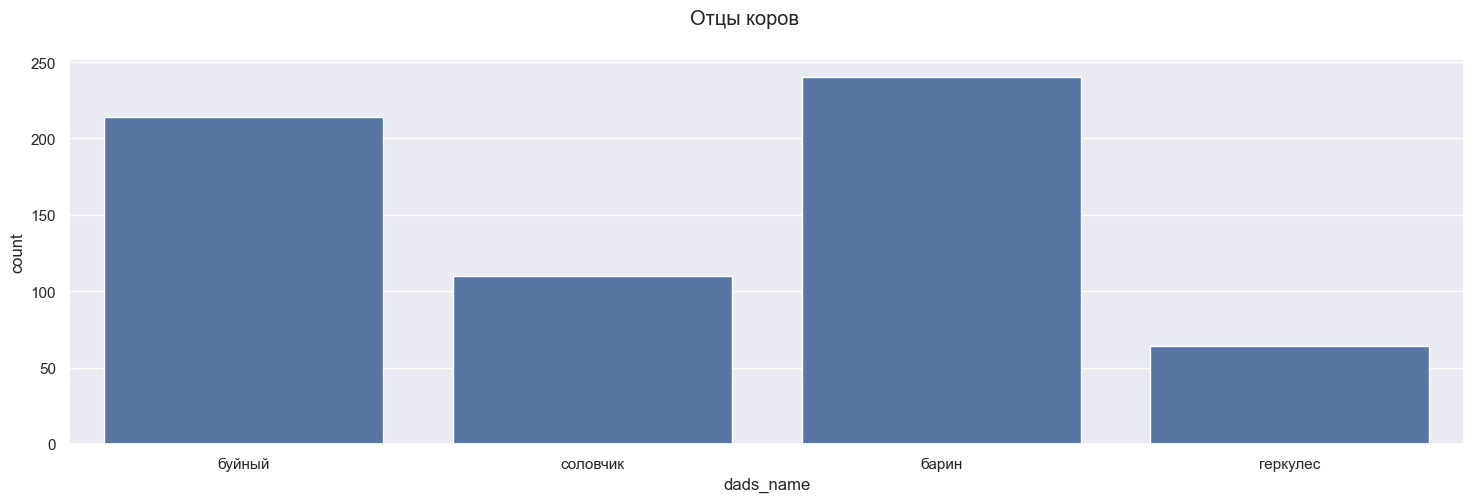

In [34]:
viz_cat_variable(ferma_dad, 'dads_name', 'Отцы коров')

### Визуализация признаков `cow_buy`

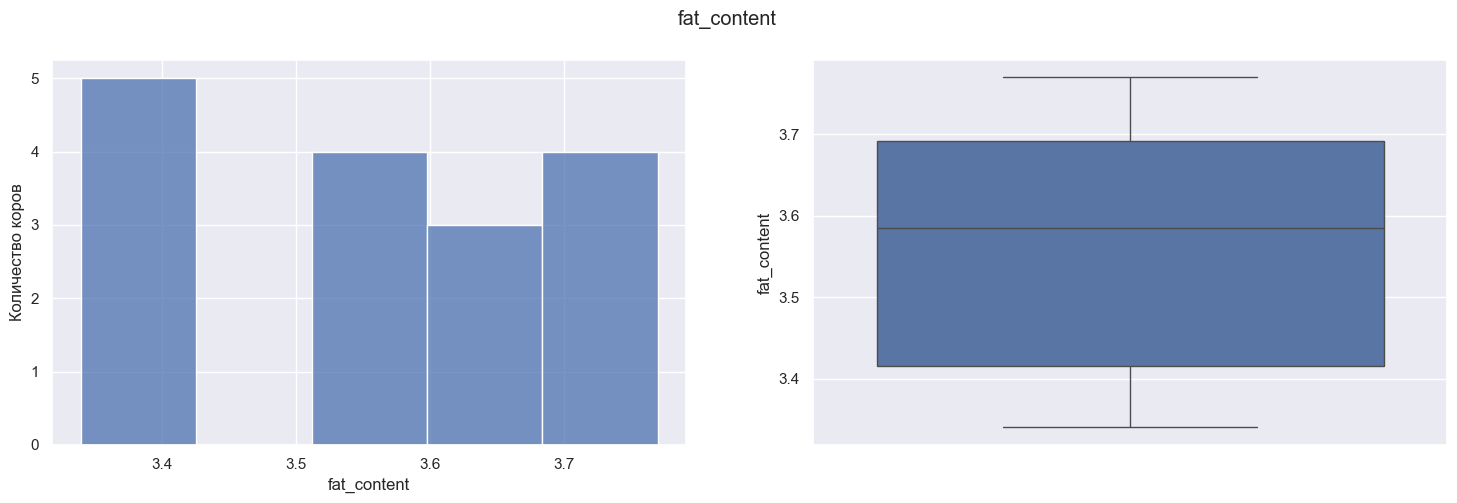

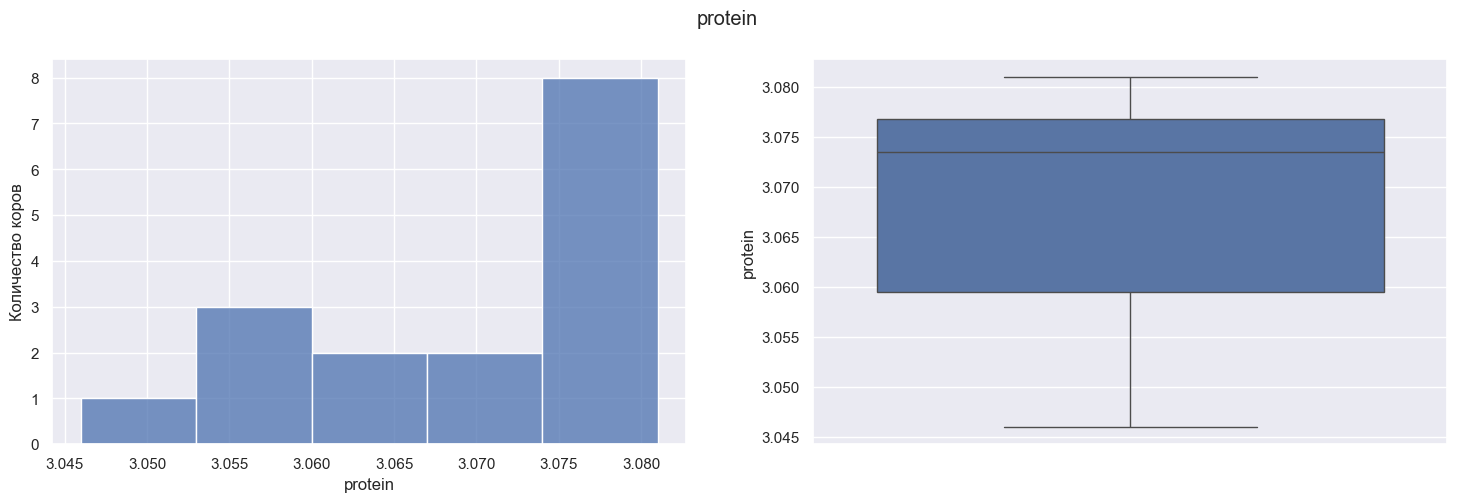

In [35]:
for col in cow_buy:
    if cow_buy[col].dtype!=object and col!='id':
        viz_num_variable(cow_buy, col, col)

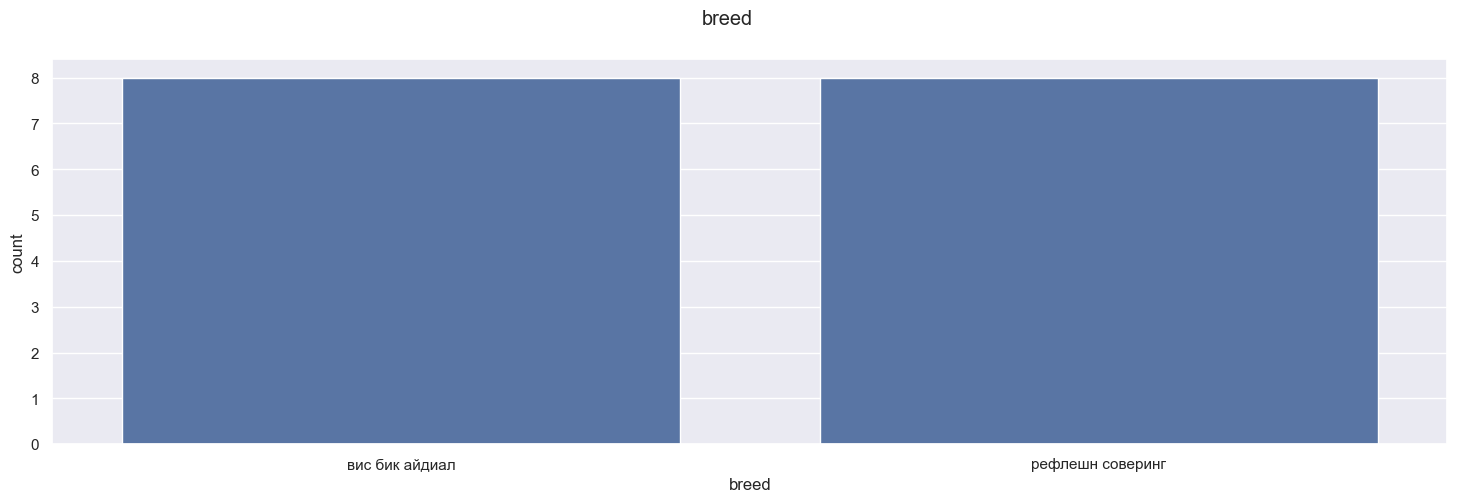

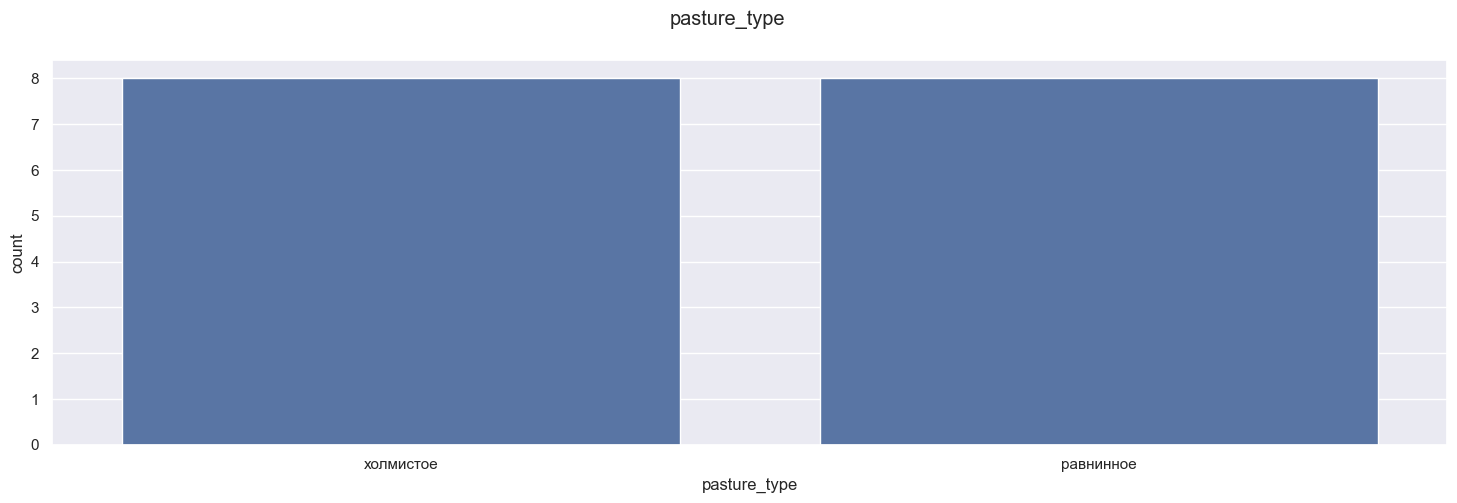

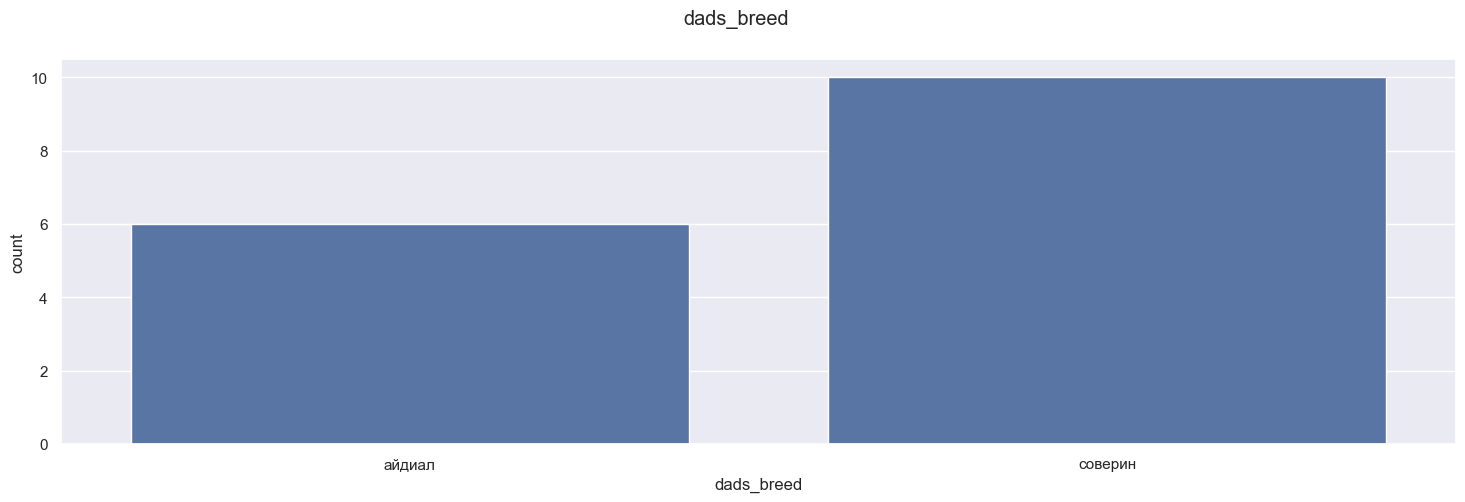

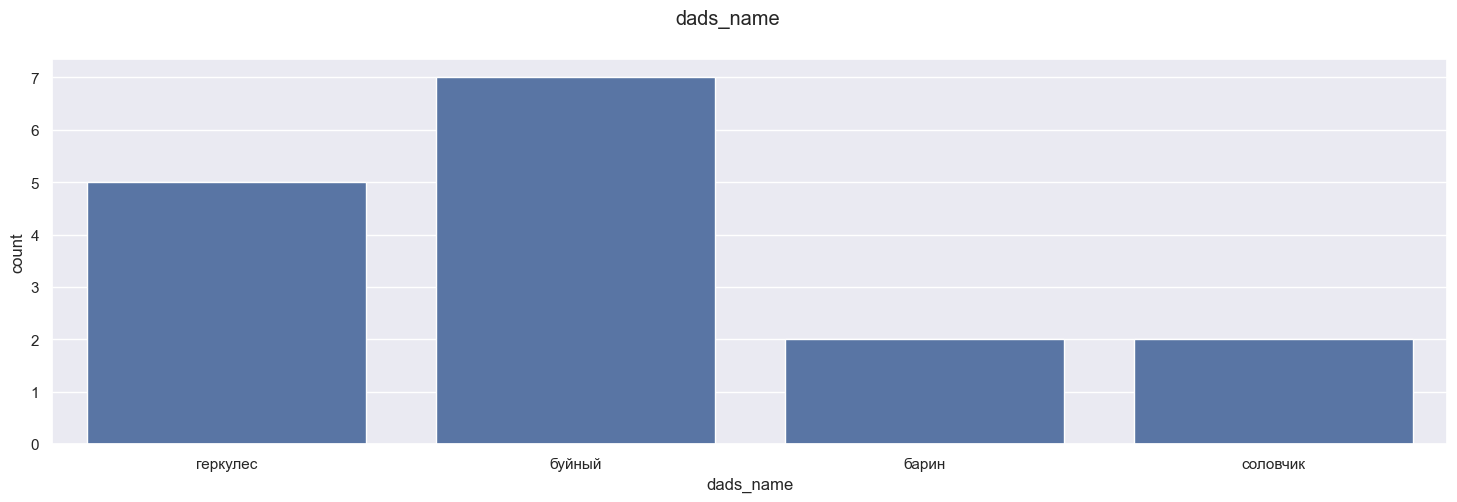

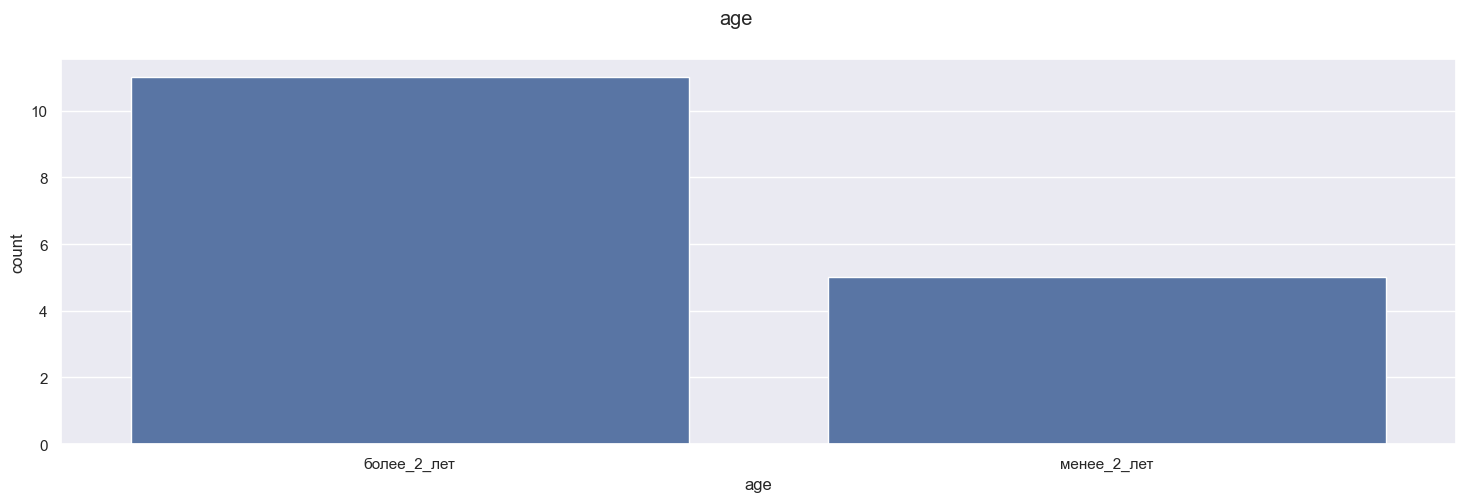

In [36]:
for col in cow_buy:
    if cow_buy[col].dtype==object and col!='id':
        viz_cat_variable(cow_buy, col, col)

### Вывод  


- Данные о удое распределены нормально. Средний удой коров более 6000 кг;
- График ЭКЕ (Энергетическая кормовая единица) смещен вправо, среднее значение 14.5;
- График сырого протеина в корме коров смещен влево, среднее значнеие около 1900;
- Отношение протеина к сахару разделено на 2 части более и менее 0.9; Среднее значение 0.91;
- Холмистых пасдбищ больше чем равнинных;
- Типы пород, пород отцов распределены поровну;
- Содержание жира в молоке в среднем 3.6. Среди данных наблюдаются выбросы слева от графика (Уберем их);
- Содержание белков в молоке распределено нормально, среднее значнеие 3.07; Среди данных наблюдаются выбросы с обоих сторон графика (Уберем их);
- Вкусное молоко дает большая часть коров фермера;
- Больше всего коров старше 2 лет;

Данные о коровах для покупки схожи с данными о коровах фермера.

## Корреляционный анализ признаков

### Диаграммы рассеяния

In [37]:
cat_ferma_main = ['breed','pasture_type','dads_breed','milk_taste','age']
num_ferma_main = ['id','milk_yield','feed_energy','crude_protein','sugar_protein_ratio','fat_content','protein']

In [38]:
def pearson_corr (column_1, column_2):

    colors = {'вис бик айдиал': 'blue', 'рефлешн соверинг': 'red'}
    plt.figure(figsize=(18,8))
    
    for breed, color in colors.items():
        filtered_main = ferma_main[ferma_main['breed']==breed]
        plt.scatter(column_1, column_2, data=filtered_main, color=color, alpha=0.5)
        print(f'''Коэффициент корреляции Пирсона {column_1} и {column_2} для породы {breed}:\
        {ferma_main.loc[ferma_main['breed'] == breed, column_1].corr(ferma_main[column_2]).round(2)}
        ''')
    plt.xlabel(column_1, size=14)
    plt.ylabel(column_2, size=14)
    plt.legend(list(colors.keys()))
    plt.title(f"Диаграмма рассеяния {column_1} и {column_2}", size = 20)
    plt.show()

In [39]:
def spearmanr_corr (column_1, column_2):

    colors = {'вис бик айдиал': 'blue', 'рефлешн соверинг': 'red'}
    plt.figure(figsize=(18,8))
    
    for breed, color in colors.items():
        filtered_main = ferma_main[ferma_main['breed']==breed]
        plt.scatter(column_1, column_2, data=filtered_main, color=color, alpha=0.5)
        rho, p = st.spearmanr(
            ferma_main.loc[ferma_main['breed'] == breed, column_1],
            ferma_main.loc[ferma_main['breed'] == breed, column_2]
        )
        print(f'''Корреляция Спирмена между {column_1} и {column_2} для породы {breed}: {rho.round(2)}
        Значение p: {p}
        ''')
    plt.xlabel(column_1, size=14)
    plt.ylabel(column_2, size=14)
    plt.legend(list(colors.keys()))
    plt.title(f"Диаграмма рассеяния {column_1} и {column_2}", size = 20)
    plt.show()

Коэффициент корреляции Пирсона milk_yield и feed_energy для породы вис бик айдиал:        0.77
        
Коэффициент корреляции Пирсона milk_yield и feed_energy для породы рефлешн соверинг:        0.76
        


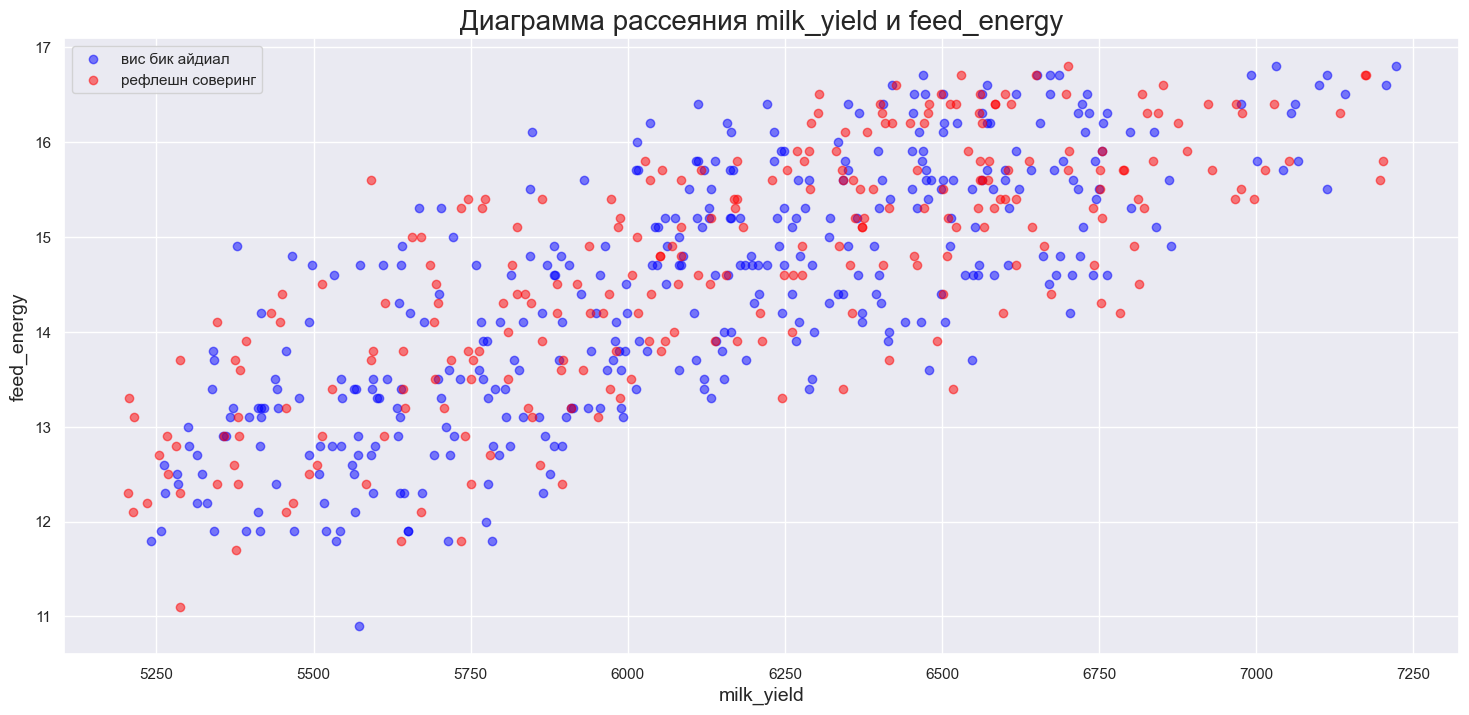

Коэффициент корреляции Пирсона milk_yield и crude_protein для породы вис бик айдиал:        0.42
        
Коэффициент корреляции Пирсона milk_yield и crude_protein для породы рефлешн соверинг:        0.48
        


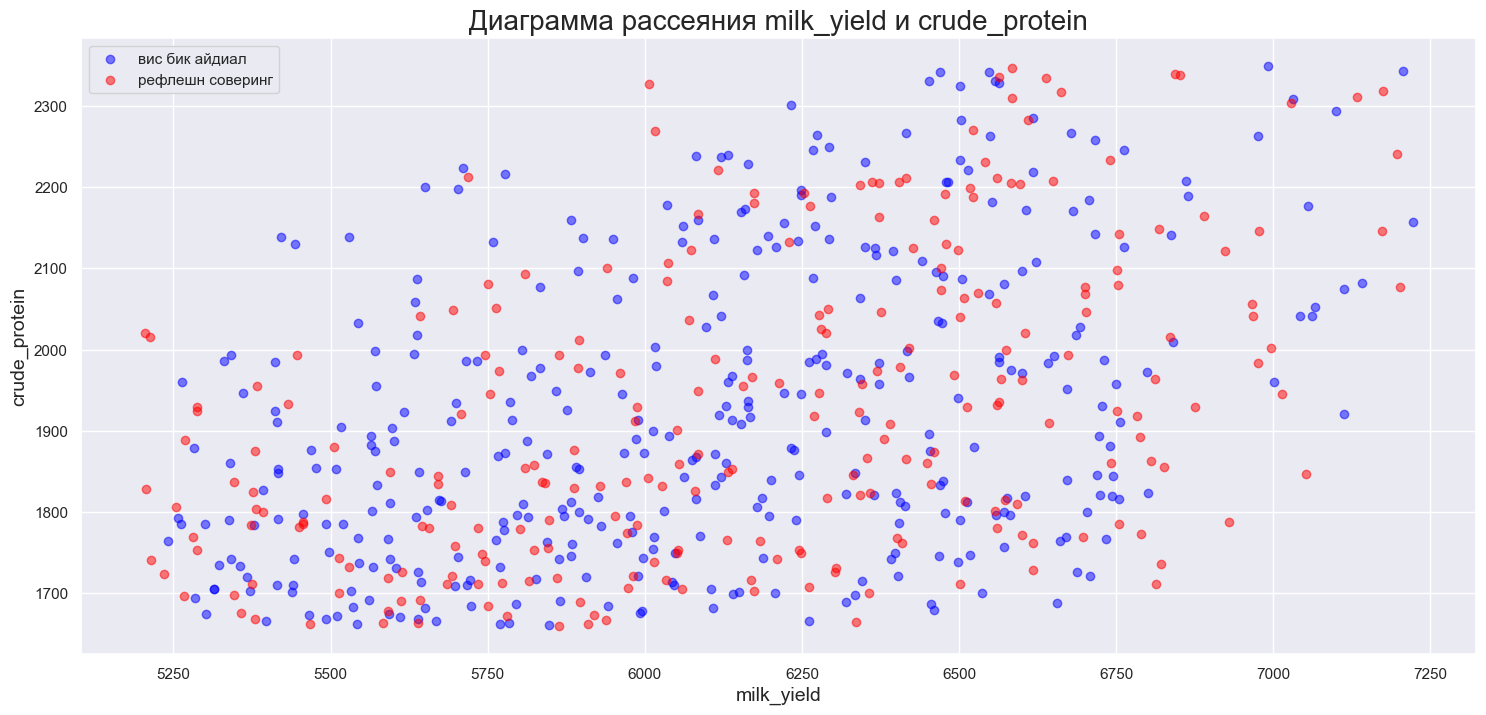

In [40]:
for i in ['feed_energy','crude_protein']:
    pearson_corr('milk_yield',i)

Коэффициент корреляции Пирсона milk_yield и feed_energy_sq для породы вис бик айдиал:        0.77
        
Коэффициент корреляции Пирсона milk_yield и feed_energy_sq для породы рефлешн соверинг:        0.76
        


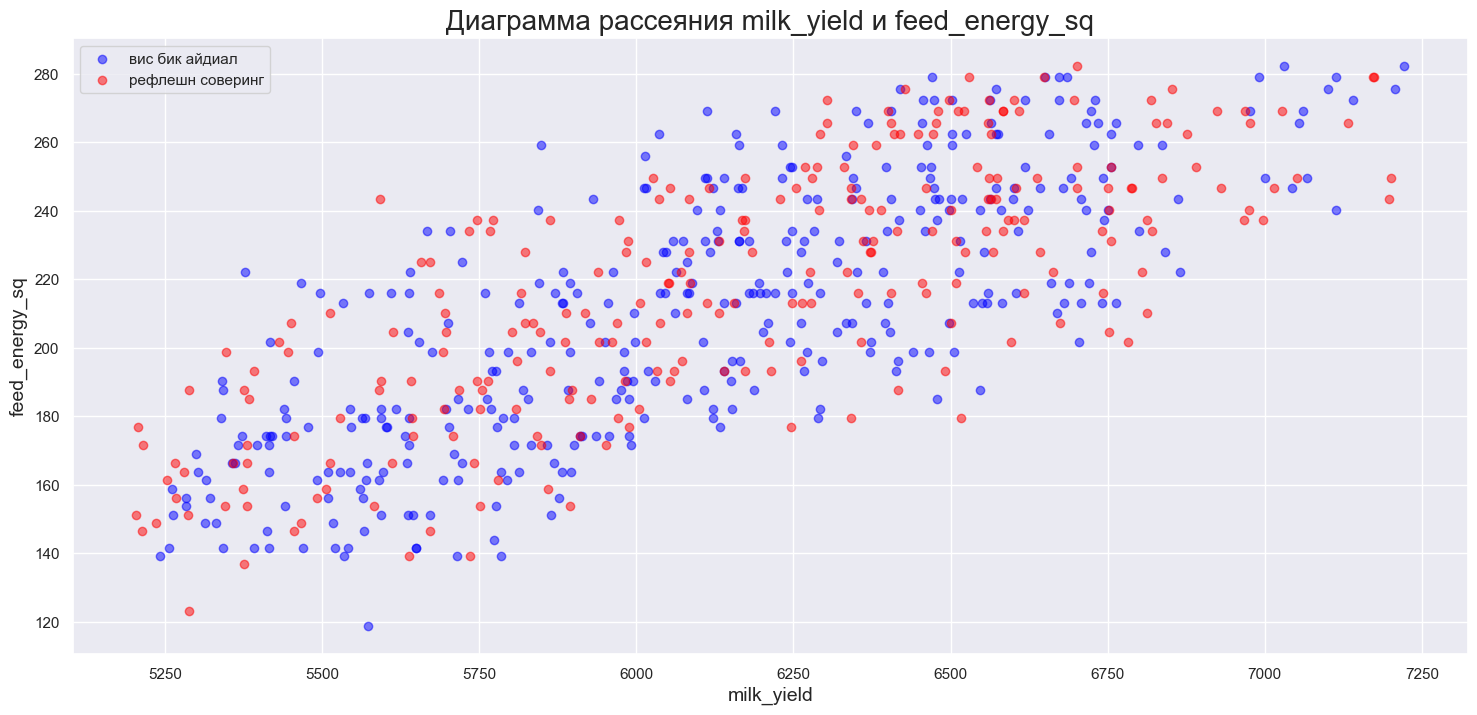

In [41]:
ferma_main['feed_energy_sq'] = ferma_main['feed_energy']**2
pearson_corr('milk_yield','feed_energy_sq')

Корреляция Спирмена между milk_yield и sugar_protein_ratio для породы вис бик айдиал: 0.79
        Значение p: 1.820054707184355e-81
        
Корреляция Спирмена между milk_yield и sugar_protein_ratio для породы рефлешн соверинг: 0.77
        Значение p: 2.0430511326997895e-52
        


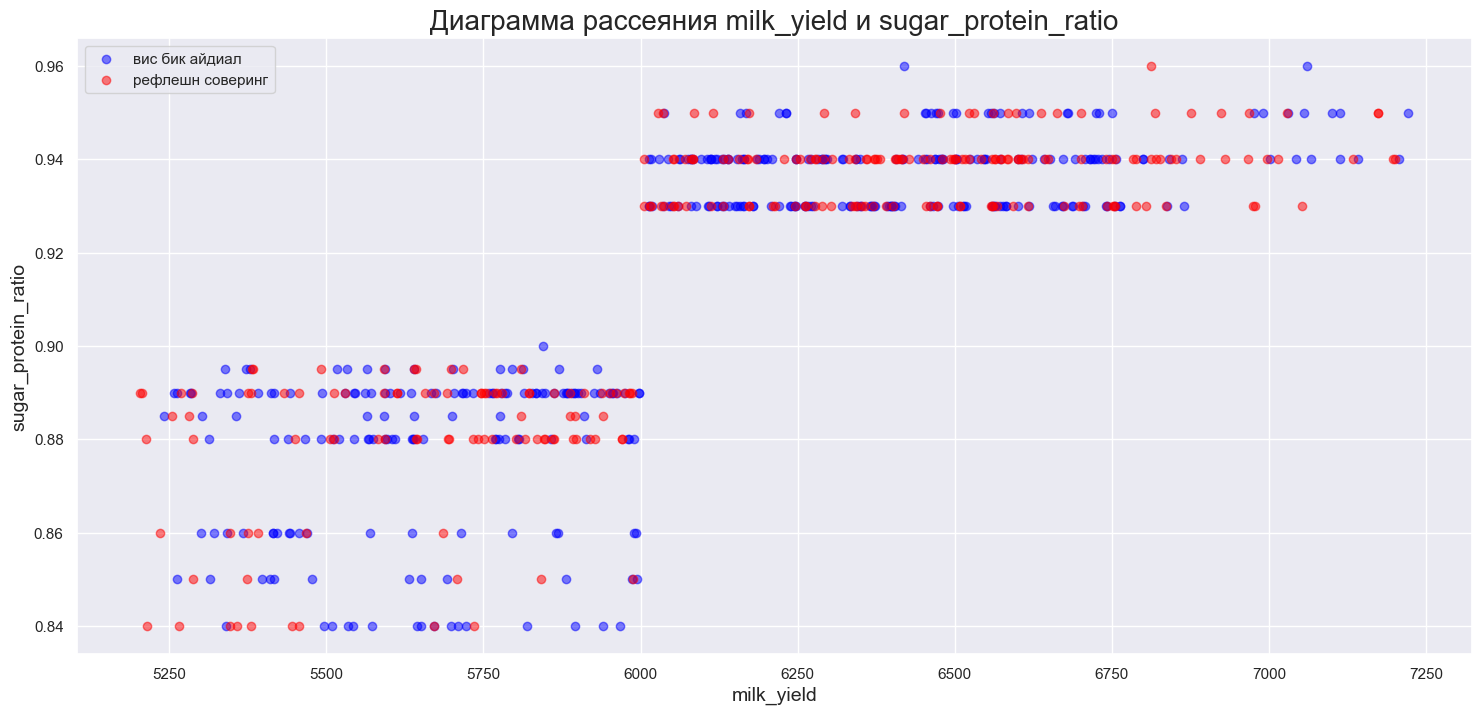

Корреляция Спирмена между milk_yield и fat_content для породы вис бик айдиал: 0.71
        Значение p: 1.017560668973784e-58
        
Корреляция Спирмена между milk_yield и fat_content для породы рефлешн соверинг: 0.64
        Значение p: 2.0357435146794836e-31
        


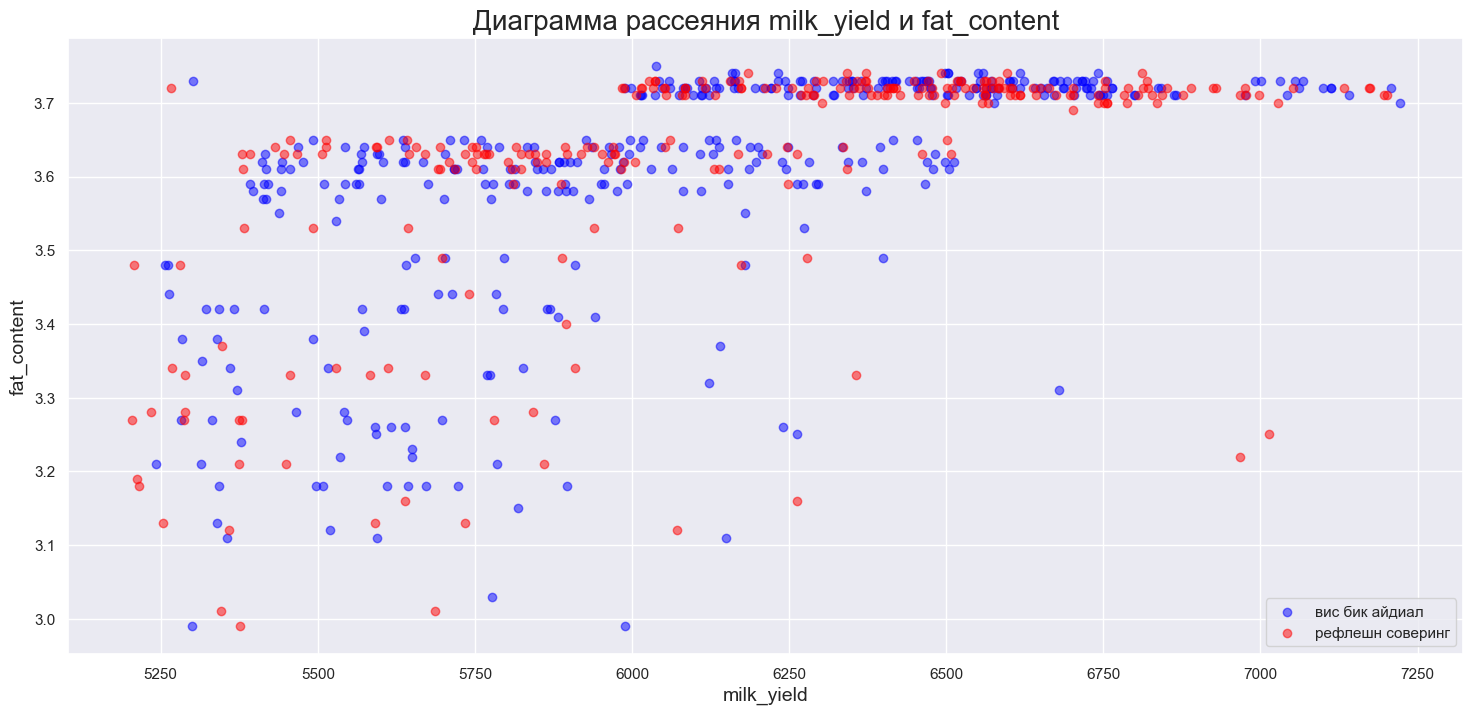

Корреляция Спирмена между milk_yield и protein для породы вис бик айдиал: 0.02
        Значение p: 0.6410678375662309
        
Корреляция Спирмена между milk_yield и protein для породы рефлешн соверинг: 0.01
        Значение p: 0.8887341394242578
        


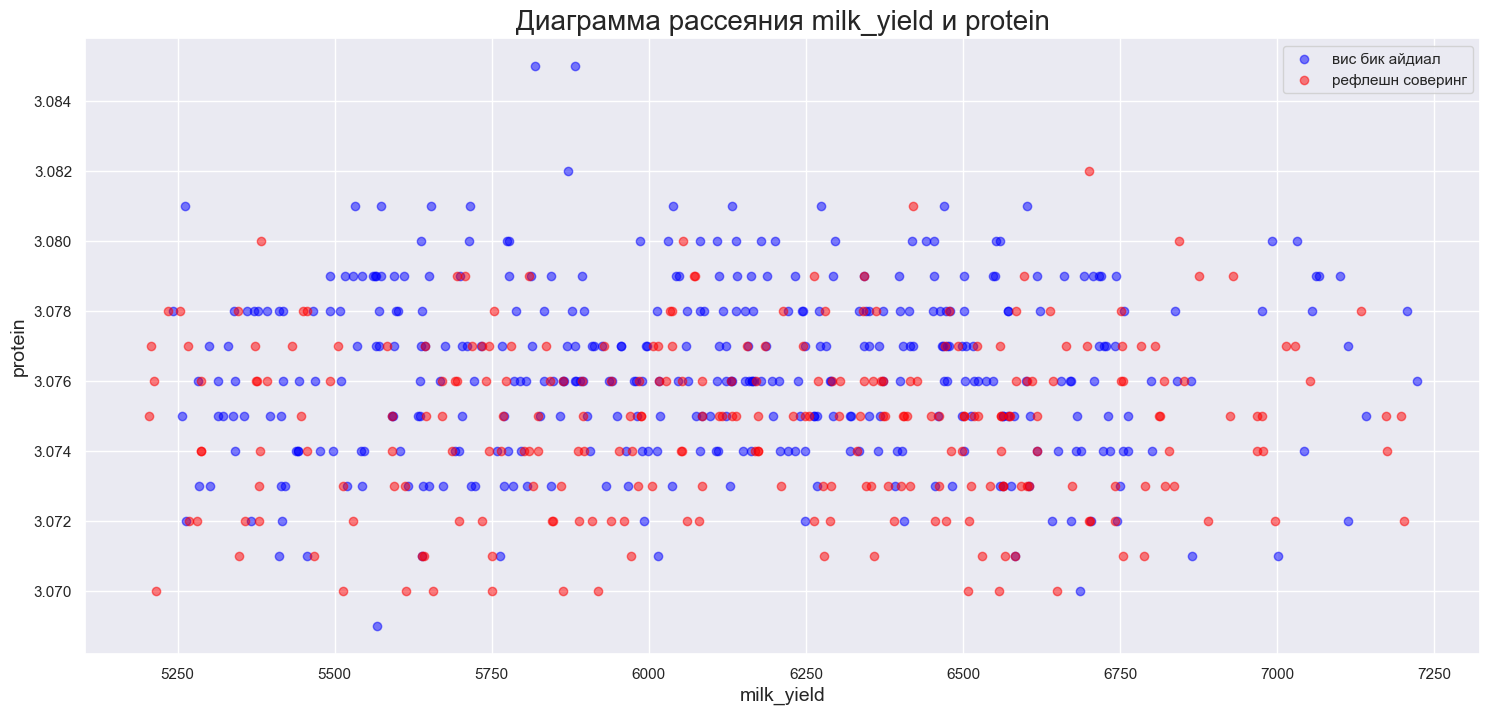

In [42]:
for i in ['sugar_protein_ratio',
         'fat_content',
         'protein']:
    spearmanr_corr('milk_yield',i)

### Выводы

 - Корреляционный анализ показал, что связь целевого признака `milk_yield` линейная с `crude_protein`.
 - C признаком `feed_energy` вырисовывается дуга, а вот с `feed_energy_sq` - связь больше похожа на линейную.
 - `sugar_protein_ratio` - больше похож на категориальный признак, так как прослеживается граница между определенными значениями.
 - Корреляция целевого признака с содежранием жира `fat_content` в молоке выше среднего, что обьясняется тем? что большая часть коров дает жирное молоко.
 - Связь `milk_yield` и `protein` не прослеживается.
 - Мультколинеарность не наблюдается. 

### Матрица корреляции

Посмотрим на коэффициенты корреляции между всеми признаками. Для этого категориальные признаки закодируем 0 и 1

Отдельно рассмотрим признаки, которые показывают нелинейную связь.

In [43]:
num_ferma_main_pr = ['id','milk_yield','feed_energy','crude_protein']
num_ferma_main_sp = ['id','sugar_protein_ratio', 'fat_content', 'protein']
ferma_main_num_pr = pd.DataFrame()
ferma_main_num_sp = pd.DataFrame()

In [44]:
ferma_main.shape

(628, 13)

In [45]:
ferma_main_num_pr['id'] = ferma_main['id']
ferma_main_num_sp['id'] = ferma_main['id']

for col in cat_ferma_main:
    ferma_main_num_pr[col+'_num'] = ferma_main[col].replace([ferma_main[col].unique()[0],ferma_main[col].unique()[1]],[0,1])

ferma_main_num_pr = pd.merge(ferma_main[num_ferma_main_pr], ferma_main_num_pr, on='id', how='inner')
ferma_main_num_sp = pd.merge(ferma_main_num_pr[['id','milk_yield']], ferma_main[num_ferma_main_sp], on='id', how='inner')


In [46]:
ferma_main_num_pr

,id,milk_yield,feed_energy,crude_protein,breed_num,pasture_type_num,dads_breed_num,milk_taste_num,age_num
0,1,5863,14.2,1743,0,0,0,0,0
1,2,5529,12.8,2138,0,0,1,0,1
2,3,5810,14.0,1854,1,1,1,1,0
3,4,5895,12.4,2012,1,1,0,1,0
4,5,5302,12.8,1675,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...
623,625,6812,15.4,1964,1,0,0,1,0
624,626,5513,12.9,1700,1,0,1,0,1
625,627,5970,14.4,1837,1,1,1,1,0
626,628,5746,13.8,1994,1,0,1,0,0


In [47]:
ferma_main_num_sp

,id,milk_yield,sugar_protein_ratio,fat_content,protein
0,1,5863,0.890,3.58,3.076
1,2,5529,0.890,3.54,3.079
2,3,5810,0.885,3.59,3.074
3,4,5895,0.885,3.40,3.075
4,5,5302,0.885,3.73,3.073
...,...,...,...,...,...
623,625,6812,0.940,3.74,3.075
624,626,5513,0.880,3.64,3.073
625,627,5970,0.880,3.64,3.075
626,628,5746,0.890,3.64,3.077


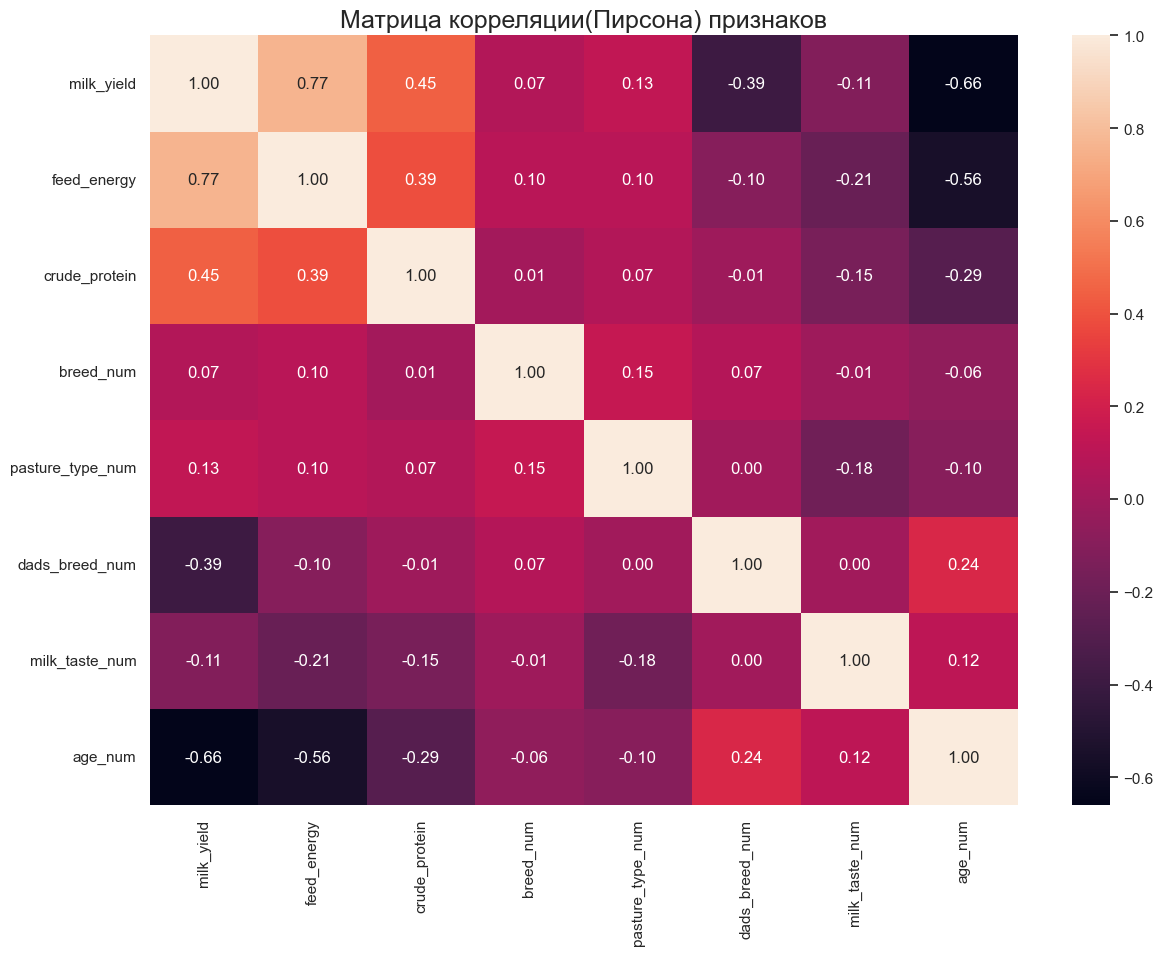

In [48]:
plt.figure(figsize=(14,10))
sns.heatmap(ferma_main_num_pr.loc[ : , ferma_main_num_pr.columns != 'id'].corr(), fmt=".2f", annot=True)

plt.title('Матрица корреляции(Пирсона) признаков', size = 18)
plt.show()

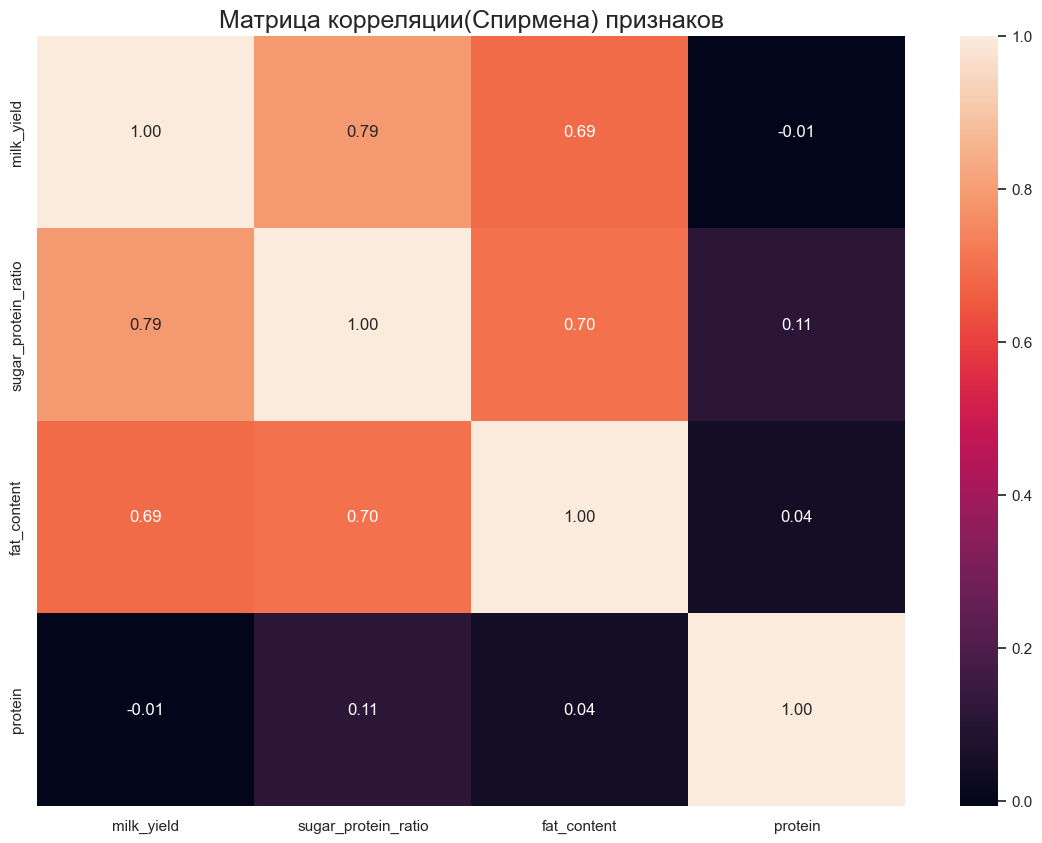

In [49]:
plt.figure(figsize=(14,10))
sns.heatmap(ferma_main_num_sp.loc[ : , ferma_main_num_sp.columns != 'id'].corr(method='spearman'), fmt=".2f", annot=True)
plt.title('Матрица корреляции(Спирмена) признаков', size = 18)
plt.show()

### Выводы


Рассмотрим сначала категориальные признаки, которые мы закодировали в количественные:
- `breed_num` - Значимой взаимосвязи породы быков с остальными признаками не наблюдается, но на количество белка `protein` она влияет, пускай и не сильно. Молоко коров породы `вис бик айдиал`(0) больше насыщенно белком, чем `рефлешн соверинг`(1).
- `pasture_type_num` - Тип пастбища так же не сильно влияет на признаки, однако вносит вклад в `milk_yield`,`feed_energy`,`protein`. "Холмистое"(1) пастбище положительно влияет на эти признаки, в отличии от `Равнинное`(0). Небольшая корреляция с породой вероятно связана с тем, что `рефлешн соверинг`(1) больше распространены на `Холмистые` полях.
- `dads_breed_num` - Наблюдается явная обратная корреляция породы отца с Удоем `milk_yield`, что означает, что у коров с породой папы `Соверин` удой больше, чем у `Айдиал`.
- `milk_taste_num` - Все очвидно, вкуснее молоко у тех коров, признаки корма которых выше.
- `age_num` - `milk_yield`, `feed_energy`, `sugar_protein_ratio`, `fat_content` молока больше у коров возраст которых `более 2 лет`. Так же обнаруженна корреляция с породой папы: продолжительность жизни больше у коров, которых порода папы - `вис бик айдиал`

Количественные признаки рассмотрим подробнее относительно Удоя молока в следующем пункте. 

## Модель линейной регрессии - регрессия

In [50]:
def model_lr(X, y, cat_ferma_main, num_ferma_main):
    RANDOM_STATE=42
    # Разбиваем данные на тренировочную и тестовоую выборку
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        random_state=RANDOM_STATE
    )
    
    # Кодируем категориальные признаки
    encoder = OneHotEncoder(drop='first',sparse_output=False)
    
    X_train_ohe = encoder.fit_transform(X_train[cat_ferma_main])
    X_test_ohe = encoder.transform(X_test[cat_ferma_main])
    
    encoder_col_names=encoder.get_feature_names_out()
    
    # Масштабируем количественные признаки
    scaler = StandardScaler()
    
    X_train_scaled = scaler.fit_transform(X_train[num_ferma_main])
    X_test_scaled = scaler.transform(X_test[num_ferma_main])
    
    # При кодировке и масштабировании мы получили массивы, вернем их в датафреймы и обьеденим
    X_train_ohe = pd.DataFrame(X_train_ohe, columns=encoder_col_names)
    X_test_ohe = pd.DataFrame(X_test_ohe, columns=encoder_col_names)
    
    X_train_scaled = pd.DataFrame(X_train_scaled, columns=num_ferma_main)
    X_test_scaled = pd.DataFrame(X_test_scaled, columns=num_ferma_main)
    
    X_train = pd.concat([X_train_ohe, X_train_scaled], axis=1)
    X_test = pd.concat([X_test_ohe, X_test_scaled], axis=1)
    
    # Обучаем модель линейной регрессии на тренировочных данных и предсказываем значения на тестовых данных
    model_lr = LinearRegression()
    model_lr.fit(X_train,y_train)
    predictions = model_lr.predict(X_test)
    return (X_train, X_test, y_train, y_test, predictions)

In [51]:
def residuals_model_lr(model_lr, X, y, cat_ferma_main, num_ferma_main):
    model = model_lr(X, y, cat_ferma_main, num_ferma_main)
    residuals = model[3] - model[4]

    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15,5))
    axes[0].hist(x=residuals)
    axes[0].set_title('Гистограмма распределения остатков')
    axes[0].set_xlabel('Остатки')
    
    axes[1].scatter(x= model[4], y=residuals)
    axes[1].set_xlabel('Предсказания модели')
    axes[1].set_ylabel('Остатки')
    axes[1].set_title('Анализ дисперсии')
    plt.show()

In [52]:
def metrics(model_lr, X, y, cat_ferma_main, num_ferma_main):
    model = model_lr(X, y, cat_ferma_main, num_ferma_main)
    
    print("R2:",round(r2_score(model[3], model[4]),3))
    print("MSE:",round(mean_squared_error(model[3], model[4]),3))
    print("RMSE:",round(root_mean_squared_error(model[3], model[4]),3))
    print("MAE:",round(mean_absolute_error(model[3], model[4]),3))

### Первая модель

#### Подготовка данных

In [53]:
ferma_main

,id,milk_yield,feed_energy,crude_protein,sugar_protein_ratio,breed,pasture_type,dads_breed,fat_content,protein,milk_taste,age,feed_energy_sq
0,1,5863,14.2,1743,0.890,вис бик айдиал,равнинное,айдиал,3.58,3.076,вкусно,более_2_лет,201.64
1,2,5529,12.8,2138,0.890,вис бик айдиал,равнинное,соверин,3.54,3.079,вкусно,менее_2_лет,163.84
2,3,5810,14.0,1854,0.885,рефлешн соверинг,холмистое,соверин,3.59,3.074,не вкусно,более_2_лет,196.00
3,4,5895,12.4,2012,0.885,рефлешн соверинг,холмистое,айдиал,3.40,3.075,не вкусно,более_2_лет,153.76
4,5,5302,12.8,1675,0.885,вис бик айдиал,равнинное,соверин,3.73,3.073,вкусно,менее_2_лет,163.84
...,...,...,...,...,...,...,...,...,...,...,...,...,...
624,625,6812,15.4,1964,0.940,рефлешн соверинг,равнинное,айдиал,3.74,3.075,не вкусно,более_2_лет,237.16
625,626,5513,12.9,1700,0.880,рефлешн соверинг,равнинное,соверин,3.64,3.073,вкусно,менее_2_лет,166.41
626,627,5970,14.4,1837,0.880,рефлешн соверинг,холмистое,соверин,3.64,3.075,не вкусно,более_2_лет,207.36
627,628,5746,13.8,1994,0.890,рефлешн соверинг,равнинное,соверин,3.64,3.077,вкусно,более_2_лет,190.44


In [54]:
X = ferma_main.drop('milk_yield',axis=1)
y = ferma_main['milk_yield']

cat_ferma_main = ['breed','pasture_type','dads_breed','age']
num_ferma_main = ['feed_energy','crude_protein','sugar_protein_ratio']

#### Обучение модели и оценка качества

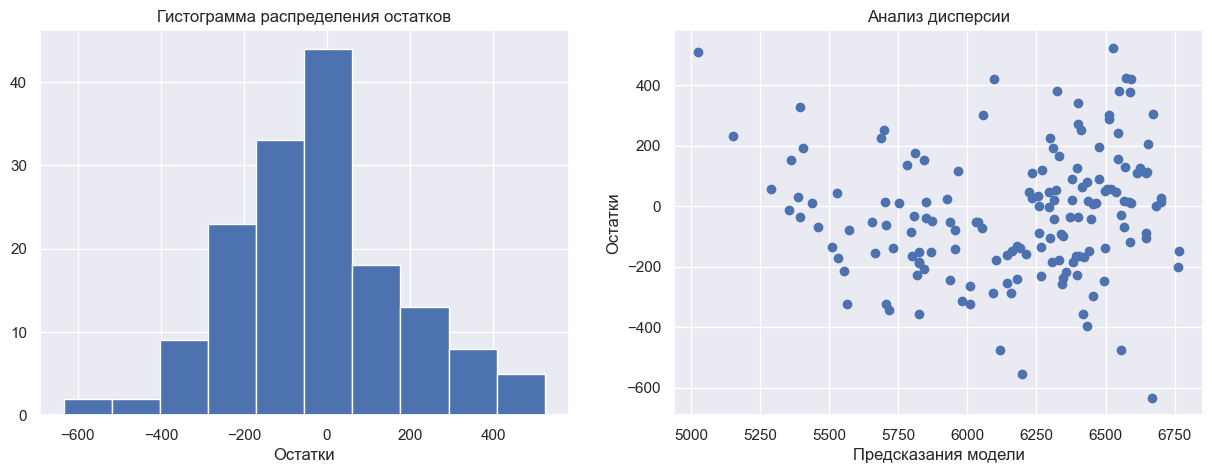

R2: 0.784
MSE: 43887.015
RMSE: 209.492
MAE: 164.242


In [55]:
# Анализируем остатки и дисперсию
residuals_model_lr(model_lr, X, y, cat_ferma_main, num_ferma_main)
# Получаем метрики качества модели
metrics(model_lr, X, y, cat_ferma_main, num_ferma_main)

#### Вывод

- Гистограмма показывает, что большинство остатков в диапазоне от 0 до 100. И при этом колокол смещен немного влево. Это значит, что модель недостаточно точно предсказывает целевой признак
- Анализ дисперсии показывает, что остатки распределена неравномерно и модель на больших значениях целевого признака дисперсия возрастает.

Попробуем исключить нелинейность связи входных признаков с целевым.

### Обучение второй модели

#### Подготовка данных

In [56]:
# Преобразуем sugar_protein_ratio в категориальная бинарный тип

ferma_main_model = ferma_main[:]
ferma_main_model['sugar_protein_ratio'] = ferma_main_model['sugar_protein_ratio'].apply(
    lambda x: 'более_0.92' if x > 0.913 else 'менее_0.92')

In [57]:
X = ferma_main_model.drop('milk_yield',axis=1)
y = ferma_main_model['milk_yield']
cat_ferma_main = ['breed','pasture_type','dads_breed','age','sugar_protein_ratio']
num_ferma_main = ['feed_energy_sq','crude_protein']

#### Обучение модели и оценка качества

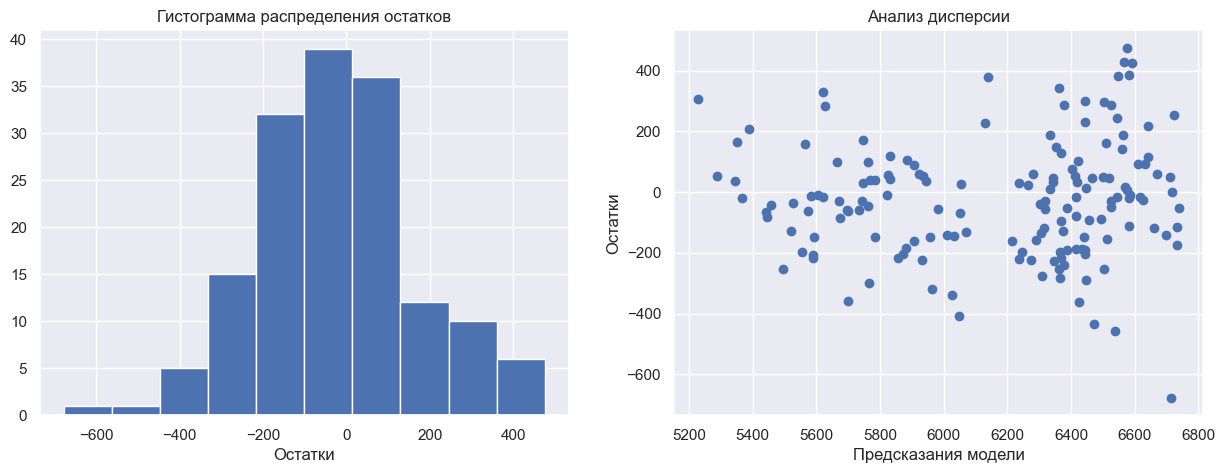

R2: 0.818
MSE: 37030.911
RMSE: 192.434
MAE: 149.04


In [58]:
# Анализируем остатки и дисперсию
residuals_model_lr(model_lr, X, y, cat_ferma_main, num_ferma_main)
# Получаем метрики качества модели
metrics(model_lr, X, y, cat_ferma_main, num_ferma_main)

#### Вывод

- Гистограмма показывает, что большинство остатков в районе 0. Колокол ровнее, чем в предудщей модели.
- Анализ дисперсии показывает, что остатки распределена более равномерно, но можно еще улучшить.

Попробуем исключить нелинейность связи входных признаков с целевым.

### Третья модель

#### Подготовка данных

In [59]:
# добавление столбца с именами пап коров
ferma_main_model = ferma_main_model.merge(ferma_dad, on='id')

In [60]:
X = ferma_main_model.drop('milk_yield',axis=1)
y = ferma_main_model['milk_yield']
cat_ferma_main = ['breed','pasture_type','dads_breed','age','sugar_protein_ratio','dads_name']
num_ferma_main = ['feed_energy_sq','crude_protein']

#### Обучение модели и оценка качества

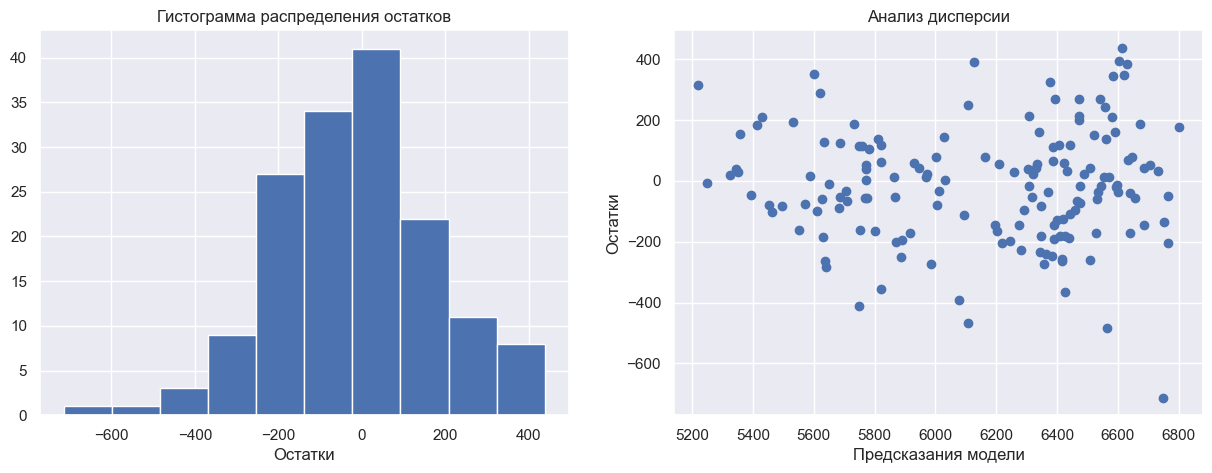

R2: 0.825
MSE: 35673.89
RMSE: 188.875
MAE: 146.163


In [61]:
# Анализируем остатки и дисперсию
residuals_model_lr(model_lr, X, y, cat_ferma_main, num_ferma_main)
# Получаем метрики качества модели
metrics(model_lr, X, y, cat_ferma_main, num_ferma_main)

#### Вывод

- Гистограмма показывает, что большенство остатков в районе 0. И при этом колокол стал ровнее, что означает, что остатки распределены номрально. 
- Анализ дисперсии показывает, что остатки распределена равномерно.

- Сравнение метрики качества R2 показывает, что у третьей модели оно самое высокое - 0.848
- Метрики MSE, RMSE, MAE - у третьей модели самые наименьшие

In [62]:
model = model_lr(X, y, cat_ferma_main, num_ferma_main)
interval = st.norm.interval(confidence= 0.95 , loc=np.mean(model[4]), scale=st.sem(model[4]))

print(f'Доверительный интервал модели: {interval[0].round(2)} - {interval[1].round(2)}')

Доверительный интервал модели: 6092.34 - 6221.38


## Прогноз удоя коров

In [63]:
# увеличим средние значения каждого признака на 5% (согласно условию)
cow_buy['feed_energy']= (ferma_main['feed_energy'].mean() * 1.05).round(2)
cow_buy['feed_energy_sq']= (cow_buy['feed_energy']**2).round(2)
cow_buy['crude_protein']= (ferma_main['crude_protein'].mean() * 1.05).round(2)
cow_buy['sugar_protein_ratio']= (ferma_main['sugar_protein_ratio'].mean() * 1.05).round(2)

#снова преобразуем количесвтенный признак в категориальный 
cow_buy_model = cow_buy[:]
cow_buy_model['sugar_protein_ratio_0967'] = cow_buy_model['sugar_protein_ratio'].apply(
    lambda x: 'более_0.967' if x > 0.967 else 'менее_0.967')
cow_buy_model = cow_buy_model.reset_index(drop=True)


In [64]:
X = ferma_main_model.drop('milk_yield', axis=1)
y = ferma_main_model['milk_yield']
cat_ferma_main = ['breed','pasture_type','dads_breed','age']
num_ferma_main = ['feed_energy_sq','crude_protein']

RANDOM_STATE=42
# Разбиваем данные на тренировочную и тестовоую выборку
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    random_state=RANDOM_STATE
)
X_cow = cow_buy_model
# Кодируем категориальные признаки
encoder = OneHotEncoder(drop='first',sparse_output=False)

X_train_ohe = encoder.fit_transform(X_train[cat_ferma_main])
X_cow_ohe = encoder.transform(X_cow[cat_ferma_main])

encoder_col_names=encoder.get_feature_names_out()

# Масштабируем количественные признаки
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train[num_ferma_main])
X_cow_scaled = scaler.transform(X_cow[num_ferma_main])

# При кодировке и масштабировании мы получили массивы, вернем их в датафреймы и обьеденим
X_train_ohe = pd.DataFrame(X_train_ohe, columns=encoder_col_names)
X_cow_ohe = pd.DataFrame(X_cow_ohe, columns=encoder_col_names)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=num_ferma_main)
X_cow_scaled = pd.DataFrame(X_cow_scaled, columns=num_ferma_main)

X_train = pd.concat([X_train_ohe, X_train_scaled], axis=1)
X_cow = pd.concat([X_cow_ohe, X_cow_scaled], axis=1)

# Обучаем модель линейной регрессии на тренировочных данных и предсказываем значения на тестовых данных
model_lr = LinearRegression()
model_lr.fit(X_train,y_train)
predictions = model_lr.predict(X_cow)

In [65]:
for i in range(len(cow_buy_model)):
    cow_buy_model.loc[i,'milk_yield'] = predictions[i].round(2)

In [66]:
cow_buy_model = cow_buy_model[cow_buy_model['milk_yield'] > 6000][:]
cow_buy_model

,breed,pasture_type,dads_breed,dads_name,fat_content,protein,age,feed_energy,feed_energy_sq,crude_protein,sugar_protein_ratio,sugar_protein_ratio_0967,milk_yield
0,вис бик айдиал,холмистое,айдиал,геркулес,3.58,3.076,более_2_лет,15.28,233.48,2019.95,0.96,менее_0.967,6519.53
2,рефлешн соверинг,равнинное,соверин,барин,3.59,3.074,более_2_лет,15.28,233.48,2019.95,0.96,менее_0.967,6201.20
3,рефлешн соверинг,холмистое,айдиал,буйный,3.40,3.061,более_2_лет,15.28,233.48,2019.95,0.96,менее_0.967,6522.78
4,рефлешн соверинг,равнинное,айдиал,буйный,3.64,3.074,более_2_лет,15.28,233.48,2019.95,0.96,менее_0.967,6488.07
6,вис бик айдиал,равнинное,соверин,буйный,3.57,3.079,более_2_лет,15.28,233.48,2019.95,0.96,менее_0.967,6197.95
7,рефлешн соверинг,холмистое,айдиал,буйный,3.40,3.079,менее_2_лет,15.28,233.48,2019.95,0.96,менее_0.967,6228.88
8,вис бик айдиал,холмистое,соверин,соловчик,3.73,3.055,более_2_лет,15.28,233.48,2019.95,0.96,менее_0.967,6232.66
9,рефлешн соверинг,равнинное,соверин,геркулес,3.73,3.073,более_2_лет,15.28,233.48,2019.95,0.96,менее_0.967,6201.20
10,вис бик айдиал,холмистое,айдиал,геркулес,3.68,3.046,более_2_лет,15.28,233.48,2019.95,0.96,менее_0.967,6519.53
12,рефлешн соверинг,холмистое,айдиал,буйный,3.40,3.065,более_2_лет,15.28,233.48,2019.95,0.96,менее_0.967,6522.78


### Выводы

- Построены модели линейной регрессии по данным из датасета farm_main.csv и определена по значениям метрик более точная;
- Полученное значение коэффициента R2 = 0.848;
- Применена лучшая по качеству и по точности модель к данным из датасета cow_buy.csv и получен прогноз удоя коров;
- Определены коровы с удоем не менее 6000 кг в год.

## Модель логистической регрессии - классификация

### Подготовка данных

In [67]:
ferma_main['milk_taste'] = ferma_main['milk_taste'].apply(lambda x: 1 if x == 'вкусно' else 0)

ferma_main_model = ferma_main
cow_buy_model['milk_taste'] = 0

X = ferma_main.drop('milk_taste', axis=1)
y = ferma_main['milk_taste']

cat_ferma_main = ['breed','pasture_type','dads_breed','age']
num_ferma_main = ['feed_energy','crude_protein','sugar_protein_ratio', 'fat_content', 'protein']

### Обучение модели

In [68]:
RANDOM_STATE=42
# Разбиваем данные на тренировочную и тестовоую выборку
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    random_state=RANDOM_STATE
)

# Кодируем категориальные признаки
encoder = OneHotEncoder(drop='first',sparse_output=False)

X_train_ohe = encoder.fit_transform(X_train[cat_ferma_main])
X_test_ohe = encoder.transform(X_test[cat_ferma_main])

encoder_col_names=encoder.get_feature_names_out()

# Масштабируем количественные признаки
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train[num_ferma_main])
X_test_scaled = scaler.transform(X_test[num_ferma_main])

# При кодировке и масштабировании мы получили массивы, вернем их в датафреймы и обьеденим
X_train_ohe = pd.DataFrame(X_train_ohe, columns=encoder_col_names)
X_test_ohe = pd.DataFrame(X_test_ohe, columns=encoder_col_names)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=num_ferma_main)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=num_ferma_main)

X_train = pd.concat([X_train_ohe, X_train_scaled], axis=1)
X_test = pd.concat([X_test_ohe, X_test_scaled], axis=1)

# Обучаем модель линейной регрессии на тренировочных данных и предсказываем значения на тестовых данных
clf = LogisticRegression()
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)

### Расчет метрик и матрица ошибок

Accuracy =  0.6050955414012739
Precision =  0.6065573770491803
Recall =  0.8409090909090909


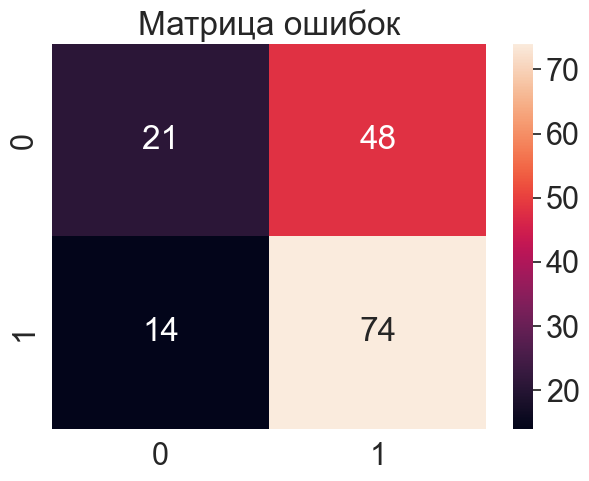

In [69]:
acc = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

plt.figure(figsize = (7,5))
cm = confusion_matrix(y_test, y_pred)

sns.set (font_scale= 2 )
sns.heatmap(cm, annot=True, fmt='d');
plt.title('Матрица ошибок')
print('Accuracy = ',acc)
print('Precision = ',precision)
print('Recall = ',recall)

#### Вывод

- Модель предсказывает 74 верных положительных значений и 48 неверных положительных;
- Для минимизации рисков необходимо сократить количество неверных положительных предсказаний, так как фермеру важно получить коров с вкусным молоком и важно не ошибиться с положительными предсказаниями.

#### Поиск наилучшего порога

In [70]:
y_proba = clf.predict_proba(X_test)[:,1]

data = pd.DataFrame(zip(y_test, y_proba, y_pred), columns = ['y_valid', 'y_proba', 'y_pred'])\
.sort_values(by='y_proba',ascending=False)

data.head()

,y_valid,y_proba,y_pred
33,0,0.848358,1
17,1,0.827956,1
85,1,0.819905,1
66,1,0.809939,1
95,1,0.790450,1


In [71]:
thresholds = [round(i,2) for i in np.linspace(0.5,1,num = 1000,endpoint=False)]

In [72]:
# создаём переменную, которая будет хранить список новых колонок
columns = []

# добавьте столбцы с новыми предсказаниями в таблицу
for i in thresholds:
    columns.append('y_pred_'+str(i))
    data['y_pred_'+str(i)] = data['y_proba'].apply(lambda x: 1 if x >= i else 0)
data.head()

,y_valid,y_proba,y_pred,y_pred_0.5,y_pred_0.51,y_pred_0.52,y_pred_0.53,y_pred_0.54,y_pred_0.55,y_pred_0.56,...,y_pred_0.91,y_pred_0.92,y_pred_0.93,y_pred_0.94,y_pred_0.95,y_pred_0.96,y_pred_0.97,y_pred_0.98,y_pred_0.99,y_pred_1.0
33,0,0.848358,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
17,1,0.827956,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
85,1,0.819905,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
66,1,0.809939,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
95,1,0.790450,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [73]:
for i in thresholds:
    cm = confusion_matrix(y_test, data['y_pred_'+str(i)])
    if cm[0][1] == 0:
        print('Порог = ',i ,'Precision = ', round(precision_score(y_test, data['y_pred_'+str(i)]), 2), 'TP =', cm[1][1])
        porog = i
        break

Порог =  0.81 Precision =  1.0 TP = 3


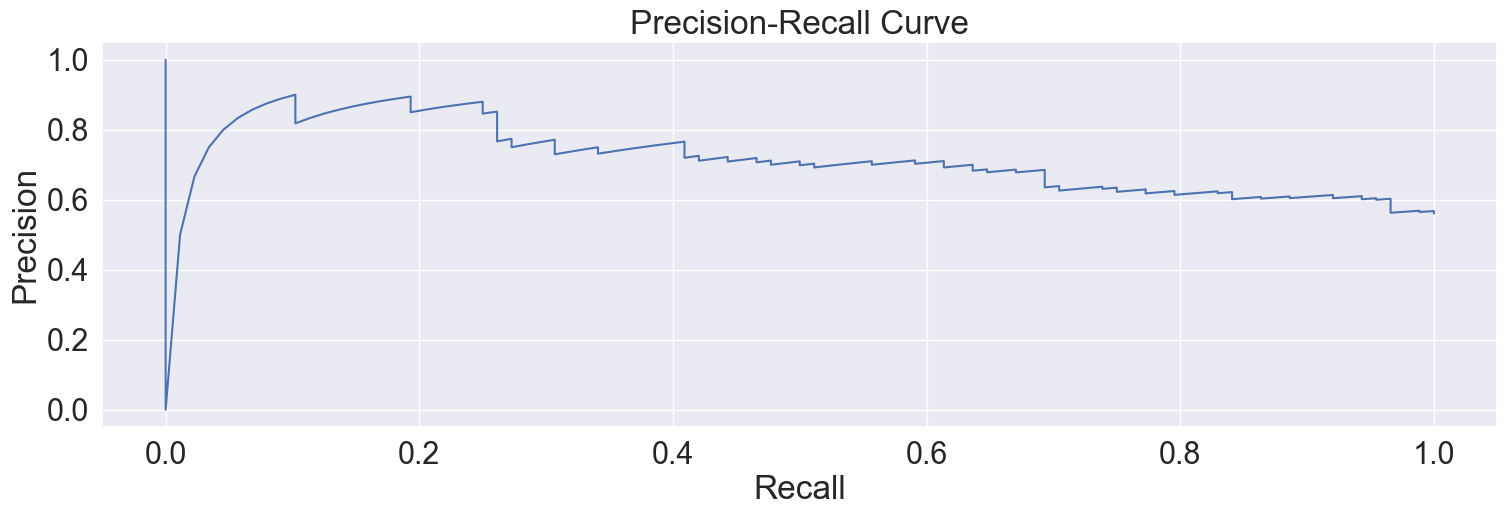

In [74]:
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

fig, ax = plt.subplots()
ax.plot(recall, precision)

ax.set_title('Precision-Recall Curve')
ax.set_ylabel('Precision')
ax.set_xlabel('Recall')

plt.show()

Accuracy =  0.4585987261146497
Precision =  1.0
Recall =  0.03409090909090909


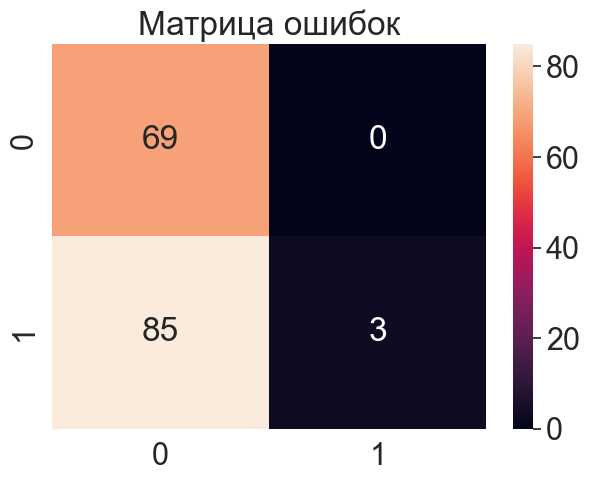

In [75]:
acc = accuracy_score(y_test, data['y_pred_'+str(porog)])
precision = precision_score(y_test, data['y_pred_'+str(porog)])
recall = recall_score(y_test, data['y_pred_'+str(porog)])

plt.figure(figsize = (7,5))
cm = confusion_matrix(y_test, data['y_pred_'+str(porog)])

sns.set (font_scale= 2 )
sns.heatmap(cm, annot=True, fmt='d');
plt.title('Матрица ошибок')
print('Accuracy = ',acc)
print('Precision = ',precision)
print('Recall = ',recall)

## Прогноз вкуса молока коров

In [76]:
cow_buy_model.head()

,breed,pasture_type,dads_breed,dads_name,fat_content,protein,age,feed_energy,feed_energy_sq,crude_protein,sugar_protein_ratio,sugar_protein_ratio_0967,milk_yield,milk_taste
0,вис бик айдиал,холмистое,айдиал,геркулес,3.58,3.076,более_2_лет,15.28,233.48,2019.95,0.96,менее_0.967,6519.53,0
2,рефлешн соверинг,равнинное,соверин,барин,3.59,3.074,более_2_лет,15.28,233.48,2019.95,0.96,менее_0.967,6201.20,0
3,рефлешн соверинг,холмистое,айдиал,буйный,3.40,3.061,более_2_лет,15.28,233.48,2019.95,0.96,менее_0.967,6522.78,0
4,рефлешн соверинг,равнинное,айдиал,буйный,3.64,3.074,более_2_лет,15.28,233.48,2019.95,0.96,менее_0.967,6488.07,0
6,вис бик айдиал,равнинное,соверин,буйный,3.57,3.079,более_2_лет,15.28,233.48,2019.95,0.96,менее_0.967,6197.95,0


In [77]:
X = ferma_main.drop('milk_taste', axis=1)
y = ferma_main['milk_taste']
X_cow = cow_buy_model

cat_ferma_main = ['breed','pasture_type','dads_breed','age']
num_ferma_main = ['feed_energy','crude_protein','sugar_protein_ratio', 'fat_content', 'protein']

RANDOM_STATE=42
# Разбиваем данные на тренировочную и тестовоую выборку
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    random_state=RANDOM_STATE
)

# Кодируем категориальные признаки
encoder = OneHotEncoder(drop='first',sparse_output=False)

X_train_ohe = encoder.fit_transform(X_train[cat_ferma_main])
X_cow_ohe = encoder.transform(X_cow[cat_ferma_main])

encoder_col_names=encoder.get_feature_names_out()

# Масштабируем количественные признаки
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train[num_ferma_main])
X_cow_scaled = scaler.transform(X_cow[num_ferma_main])

# При кодировке и масштабировании мы получили массивы, вернем их в датафреймы и обьеденим
X_train_ohe = pd.DataFrame(X_train_ohe, columns=encoder_col_names)
X_cow_ohe = pd.DataFrame(X_cow_ohe, columns=encoder_col_names)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=num_ferma_main)
X_cow_scaled = pd.DataFrame(X_cow_scaled, columns=num_ferma_main)

X_train = pd.concat([X_train_ohe, X_train_scaled], axis=1)
X_cow = pd.concat([X_cow_ohe, X_cow_scaled], axis=1)

# Обучаем модель линейной регрессии на тренировочных данных и предсказываем значения на тестовых данных
clf = LogisticRegression()
clf.fit(X_train,y_train)
y_pred = clf.predict_proba(X_cow)[:,1]

cow_buy_model['y_pred'] = y_pred

cow_buy_model['milk_taste'] = cow_buy_model['y_pred'].apply(lambda x: 'вкусное' if x >= porog else 'не вкусное')

cow_buy_model = cow_buy_model.sort_values(by = ['y_pred'], ascending = False)
cow_buy_model = cow_buy_model.drop(columns='y_pred')

cow_buy_model

,breed,pasture_type,dads_breed,dads_name,fat_content,protein,age,feed_energy,feed_energy_sq,crude_protein,sugar_protein_ratio,sugar_protein_ratio_0967,milk_yield,milk_taste
7,рефлешн соверинг,холмистое,айдиал,буйный,3.40,3.079,менее_2_лет,15.28,233.48,2019.95,0.96,менее_0.967,6228.88,вкусное
13,вис бик айдиал,холмистое,соверин,соловчик,3.73,3.079,более_2_лет,15.28,233.48,2019.95,0.96,менее_0.967,6232.66,вкусное
0,вис бик айдиал,холмистое,айдиал,геркулес,3.58,3.076,более_2_лет,15.28,233.48,2019.95,0.96,менее_0.967,6519.53,не вкусное
6,вис бик айдиал,равнинное,соверин,буйный,3.57,3.079,более_2_лет,15.28,233.48,2019.95,0.96,менее_0.967,6197.95,не вкусное
2,рефлешн соверинг,равнинное,соверин,барин,3.59,3.074,более_2_лет,15.28,233.48,2019.95,0.96,менее_0.967,6201.20,не вкусное
4,рефлешн соверинг,равнинное,айдиал,буйный,3.64,3.074,более_2_лет,15.28,233.48,2019.95,0.96,менее_0.967,6488.07,не вкусное
9,рефлешн соверинг,равнинное,соверин,геркулес,3.73,3.073,более_2_лет,15.28,233.48,2019.95,0.96,менее_0.967,6201.20,не вкусное
12,рефлешн соверинг,холмистое,айдиал,буйный,3.40,3.065,более_2_лет,15.28,233.48,2019.95,0.96,менее_0.967,6522.78,не вкусное
15,вис бик айдиал,равнинное,соверин,буйный,3.34,3.069,более_2_лет,15.28,233.48,2019.95,0.96,менее_0.967,6197.95,не вкусное
3,рефлешн соверинг,холмистое,айдиал,буйный,3.40,3.061,более_2_лет,15.28,233.48,2019.95,0.96,менее_0.967,6522.78,не вкусное


### Выводы

- Полученное значение коэффициента детерминации - 0.8;
- Лучшая по качеству и точности модель к данным и получен прогноз вкуса молока коров. Среди всех коров только две коровы будут давать не менее 6000 кг вкусного молока.

In [78]:
reccomended_cow_buy = cow_buy_model[cow_buy_model['milk_taste'] == 'вкусное'].drop(columns=['feed_energy','feed_energy_sq','crude_protein','sugar_protein_ratio','sugar_protein_ratio_0967'])
reccomended_cow_buy

,breed,pasture_type,dads_breed,dads_name,fat_content,protein,age,milk_yield,milk_taste
7,рефлешн соверинг,холмистое,айдиал,буйный,3.40,3.079,менее_2_лет,6228.88,вкусное
13,вис бик айдиал,холмистое,соверин,соловчик,3.73,3.079,более_2_лет,6232.66,вкусное


## Общий вывод

В ходе работы были изучены данные о коровах фермера, именах их отцов и коровах для покупки.

<b>Выполнено изучение исходных данных:</b>

* В них выявлены и обработаны пропуски, дeбликаты, аномалии и изменены типы данных
* Название столбцов приведены к единообразию


<b>Выполнен исследовательский анализ данных:</b>

* В среднем коровы фермера дают более 6000 кг молока
* Коровы получают питательный корм с низким содержанием протеина
* Породы коров, их отцов и типы пастбищ разделены пополам между скотом фермера
* Коровы фермера в среднем дают молоко с жирностью 3.6 и содержанем белка 3.07
* Вкусное молоко дает большая часть коров фермера
* Средний возраст коров фермера более 2 лет
* Больше всего коров имеют отцов Барин и Буйный
* Данные о коровах для покупки сходны с данными о коровах фермера

<b>Проведен корреляционный анализ признаков в датасете ferma_main.csv:</b>

* Исследование показало, что связь целевого признака "Удоя молока" линейная с признаками: Энергетическая кормовая единица и Сырой протеин
* Связь целевого признака с другими признаками не линейная
* Мультиколинеарность не наблюдается
* Среди коров найдено 2 коровы, которые смогут дать более 6000 кг вкусного молока. Их фермер можно рекомендовать к покупке, не опасаять за ложно положительные результаты модели, и с большой вероятностью ожидать прибыль  


<b>Решена задача регрессии - обучили модель линейной регрессии:</b>
* В процессе обучения более точной модели линейной регрессии переведена "СПО (Сахаро-протеиновое соотношение)" в категориальный признак, использовав границу нелинейности. Ввели новый признак "ЭКЕ в квадрате"
* Дополнительно введен признак "Имя папы".
* Данная модель показала максимальную точность и предсказала коров с удоем свыше 6000 кг молока.  


<b>Решена задача классификации - обучили логистическую регрессию:</b>
* Далее построена модель логистической регрессии на основе данных из датасета farm_main.csv и получены данные по целевому признаку "Вкус молока"
* Самое оптимальное значение порога — 0.8. При значении критической ошибки - 0, получается 1 корова истинно-положительного результата целевого признака  

<b>В результате получена рекомендация о покупке коров с необходимым удоем и вкусным молоком с минимальным риском для фермера  </b>